In [ ]:
! pip install -q kaggle

In [ ]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mostafamahmoud12","key":"3cbc2b5589b79058ffe0128348ce9e0c"}'}

In [ ]:
! mkdir ~/.kaggle

In [ ]:
! cp kaggle.json ~/.kaggle/

In [ ]:
! chmod 600 ~/.kaggle/kaggle.json

In [ ]:
! kaggle datasets list

ref                                                         title                                            size  lastUpdated          downloadCount  voteCount  usabilityRating  
----------------------------------------------------------  ----------------------------------------------  -----  -------------------  -------------  ---------  ---------------  
abdulmalik1518/mobiles-dataset-2025                         Mobiles Dataset (2025)                           20KB  2025-02-18 06:50:24           8149        150  1.0              
asinow/car-price-dataset                                    Car Price Dataset                               135KB  2025-01-26 19:53:28          25354        395  1.0              
mahmoudelhemaly/students-grading-dataset                    Student Performance & Behavior Dataset          508KB  2025-02-17 17:38:46           6282        108  1.0              
meharshanali/walmart-stocks-data-2025                       Walmart Stocks Data 2025                

In [ ]:
#!/bin/bash
! kaggle datasets download virajbagal/roco-dataset

Dataset URL: https://www.kaggle.com/datasets/virajbagal/roco-dataset
License(s): CC0-1.0
100% 6.19G/6.19G [01:27<00:00, 114MB/s] 
100% 6.19G/6.19G [01:27<00:00, 76.2MB/s]


In [ ]:
! unzip /content/roco-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: all_data/validation/radiology/images/PMC3870636_CRIM.OTOLARYNGOLOGY2013-650428.002.jpg  
  inflating: all_data/validation/radiology/images/PMC3870648_CRIM.DENTISTRY2013-378062.012.jpg  
  inflating: all_data/validation/radiology/images/PMC3871037_enm-28-326-g001.jpg  
  inflating: all_data/validation/radiology/images/PMC3872022_CRIM.MEDICINE2013-653925.001.jpg  
  inflating: all_data/validation/radiology/images/PMC3872161_CRIM.SURGERY2013-209494.001.jpg  
  inflating: all_data/validation/radiology/images/PMC3872390_CRIM.OBGYN2013-906351.001.jpg  
  inflating: all_data/validation/radiology/images/PMC3872571_OJO-6-193-g005.jpg  
  inflating: all_data/validation/radiology/images/PMC3872571_OJO-6-193-g007.jpg  
  inflating: all_data/validation/radiology/images/PMC3872649_SNI-4-150-g001.jpg  
  inflating: all_data/validation/radiology/images/PMC3872649_SNI-4-150-g014.jpg  
  inflating: all_data/validation/radiology/images/PMC38

In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
import tensorflow as tf
from tensorflow.keras.applications import Xception
from keras.applications.xception import preprocess_input
from tensorflow.keras.preprocessing.image import load_img,img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical ,plot_model
from tensorflow.keras.layers import Input ,Dense ,LSTM ,Embedding ,Dropout ,add
# from datasets import Dataset, DatasetDict
# from datasets import load_dataset
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Embedding, Reshape, Concatenate, Conv2D, Conv2DTranspose
from tensorflow.keras.layers import BatchNormalization, Activation, LeakyReLU, Dropout, Flatten, Lambda
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow.keras.backend as K

In [ ]:
import os
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

## `read dataset`

In [ ]:
dataset_path = "/content/all_data"


In [ ]:

def list_images(category, dataset_split):
    """
    category: 'radiology' or 'non-radiology'
    dataset_split: 'train', 'validation', or 'test'
    """
    image_dir = os.path.join(dataset_path, dataset_split, category, "images")
    images = [os.path.join(image_dir, img) for img in os.listdir(image_dir) if img.endswith(('.png', '.jpg', '.jpeg'))]
    return images




In [ ]:
# train datasets
radiology_train_images = list_images("radiology", "train")
print(f"Total radiology training images: {len(radiology_train_images)}")

Total radiology training images: 65420


In [ ]:
# test datasets
radiology_train_images = list_images("radiology", "test")
print(f"Total radiology test images: {len(radiology_train_images)}")

Total radiology test images: 8176


In [ ]:
# validation datasets
radiology_train_images = list_images("radiology", "validation")
print(f"Total radiology validation images: {len(radiology_train_images)}")

Total radiology validation images: 8175


In [ ]:
import pandas as pd
import os

# Define dataset paths
dataset_root = "/content/all_data"
train_csv = os.path.join(dataset_root, "train", "radiologytraindata.csv")
val_csv = os.path.join(dataset_root, "validation", "radiologyvaldata.csv")
test_csv = os.path.join(dataset_root, "test", "radiologytestdata.csv")  # Adjust if needed

# Load datasets
train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)
test_df = pd.read_csv(test_csv)


# Combine all datasets
full_dataset = pd.concat([train_df, val_df, test_df], ignore_index=True)

# Save the merged dataset
combined_csv_path = os.path.join(dataset_root, "combined_radiology_dataset.csv")
full_dataset.to_csv(combined_csv_path, index=False)

print(f"Combined dataset saved at: {combined_csv_path}")
print(f"Total records: {len(full_dataset)}")



Combined dataset saved at: /content/all_data/combined_radiology_dataset.csv
Total records: 81809


In [ ]:
full_dataset.head()

,id,name,caption
0,ROCO_00002,PMC4083729_AMHSR-4-14-g002.jpg,Computed tomography scan in axial view showin...
1,ROCO_00003,PMC2837471_IJD2009-150251.001.jpg,Bacterial contamination occurred after comple...
2,ROCO_00004,PMC2505281_11999_2007_30_Fig6_HTML.jpg,The patient had residual paralysis of the han...
3,ROCO_00005,PMC3745845_IJD2013-683423.005.jpg,Panoramic radiograph after immediate loading.\n
4,ROCO_00007,PMC4917066_amjcaserep-17-301-g001.jpg,Plain abdomen x-ray: Multiple air levels at t...


In [ ]:
train_csv = pd.read_csv(os.path.join(dataset_path, "train", "radiologytraindata.csv"))
train_csv.head()

,id,name,caption
0,ROCO_00002,PMC4083729_AMHSR-4-14-g002.jpg,Computed tomography scan in axial view showin...
1,ROCO_00003,PMC2837471_IJD2009-150251.001.jpg,Bacterial contamination occurred after comple...
2,ROCO_00004,PMC2505281_11999_2007_30_Fig6_HTML.jpg,The patient had residual paralysis of the han...
3,ROCO_00005,PMC3745845_IJD2013-683423.005.jpg,Panoramic radiograph after immediate loading.\n
4,ROCO_00007,PMC4917066_amjcaserep-17-301-g001.jpg,Plain abdomen x-ray: Multiple air levels at t...


In [ ]:
import pandas as pd
import os

csv_path = os.path.join(dataset_path, "train", "radiologytraindata.csv")

# Load the CSV file
df = pd.read_csv(csv_path)

# Show first few rows
df.head()


,id,name,caption
0,ROCO_00002,PMC4083729_AMHSR-4-14-g002.jpg,Computed tomography scan in axial view showin...
1,ROCO_00003,PMC2837471_IJD2009-150251.001.jpg,Bacterial contamination occurred after comple...
2,ROCO_00004,PMC2505281_11999_2007_30_Fig6_HTML.jpg,The patient had residual paralysis of the han...
3,ROCO_00005,PMC3745845_IJD2013-683423.005.jpg,Panoramic radiograph after immediate loading.\n
4,ROCO_00007,PMC4917066_amjcaserep-17-301-g001.jpg,Plain abdomen x-ray: Multiple air levels at t...


## ` Filters images based on type`

In [ ]:
def find_images_by_type(df, image_type, dataset_path):
    """
    Filters images based on type (e.g., CT, MRI, X-ray) from the 'caption' column.

    Args:
        df (pd.DataFrame): DataFrame containing image metadata.
        image_type (str): The type of image to search for (e.g., "CT", "X-ray").
        dataset_path (str): Root dataset path.

    Returns:
        List of image file paths matching the type.
    """
    filtered_df = full_dataset[full_dataset["caption"].str.contains(image_type, case=False, na=False)]

    # Get image file names
    image_files = filtered_df["name"].tolist()

    # Convert to full paths
    image_folder = os.path.join(dataset_path, "train", "radiology", "images")
    image_paths = [os.path.join(image_folder, img) for img in image_files]

    return image_paths

# Example Usage
ct_images = find_images_by_type(full_dataset, "CT", dataset_path)
xray_images = find_images_by_type(full_dataset, "X-ray", dataset_path)
mri_images = find_images_by_type(full_dataset, "MRI", dataset_path)

print(f"Total CT images: {len(ct_images)}")
print(f"Total X-ray images: {len(xray_images)}")
print(f"Total MRI images: {len(mri_images)}")


Total CT images: 35237
Total X-ray images: 5355
Total MRI images: 5204


In [ ]:
def find_all_image_types(df):
    """
    Finds all unique image types in the dataset based on common medical terms.

    Args:
        df (pd.DataFrame): DataFrame containing image metadata.

    Returns:
        Dict with image type as key and list of image paths as values.
    """
    image_types = ["CT", "X-ray", "MRI", "Ultrasound", "PET", "Fluoroscopy"]  # Add more if needed
    type_dict = {}

    for img_type in image_types:
        type_dict[img_type] = find_images_by_type(df, img_type, dataset_path)

    return type_dict

# Example: Get all image types
all_images = find_all_image_types(full_dataset)

# Print results
for img_type, img_list in all_images.items():
    print(f"{img_type}: {len(img_list)} images found")


CT: 35237 images found
X-ray: 5355 images found
MRI: 5204 images found
Ultrasound: 2547 images found
PET: 870 images found
Fluoroscopy: 224 images found


## ` Filters only X-ray images and their captions only`

In [ ]:
import pandas as pd
import os

# Define dataset paths
dataset_root = "/content/all_data"
train_csv = os.path.join(dataset_root, "train", "radiologytraindata.csv")
val_csv = os.path.join(dataset_root, "validation", "radiologyvaldata.csv")
test_csv = os.path.join(dataset_root, "test", "radiologytestdata.csv")  # Adjust if needed

# ✅ Load datasets and explicitly add the 'dataset' column
train_df = pd.read_csv(train_csv)
train_df["dataset"] = "train"

val_df = pd.read_csv(val_csv)
val_df["dataset"] = "validation"

test_df = pd.read_csv(test_csv)
test_df["dataset"] = "test"

# ✅ Combine all datasets
full_dataset = pd.concat([train_df, val_df, test_df], ignore_index=True)

# ✅ Save the merged dataset
combined_csv_path = os.path.join(dataset_root, "combined_radiology_dataset.csv")
full_dataset.to_csv(combined_csv_path, index=False)

print(f"✅ Combined dataset saved at: {combined_csv_path}")
print(f"✅ Total records: {len(full_dataset)}")

✅ Combined dataset saved at: /content/all_data/combined_radiology_dataset.csv
✅ Total records: 81809


In [ ]:
def find_xray_images_and_captions(df, dataset_path):
    """
    Filters only X-ray images and their captions from the full dataset.

    Args:
        df (pd.DataFrame): Combined DataFrame containing image metadata.
        dataset_path (str): Root dataset path.

    Returns:
        List of tuples (image_path, caption).
    """
    # ✅ Check if the 'dataset' column exists

    # ✅ Filter rows where the caption contains "x-ray" (handling variations like "x ray" or "X-ray")
    xray_df = df[df["caption"].str.contains(r"\b[xX][- ]?ray\b", case=False, na=False, regex=True)]

    # ✅ Get image file names and captions
    xray_images = xray_df["name"].tolist()
    xray_captions = xray_df["caption"].tolist()

    # ✅ Convert filenames to full paths based on dataset source (train, validation, test)
    xray_paths = []
    for img_name, dataset_type in zip(xray_images, xray_df["dataset"]):
        image_folder = os.path.join(dataset_path, dataset_type, "radiology", "images")
        xray_paths.append(os.path.join(image_folder, img_name))

    return list(zip(xray_paths, xray_captions))


# ✅ Get all X-ray images and captions
xray_data = find_xray_images_and_captions(full_dataset, dataset_root)

print(f"✅ Total X-ray images found: {len(xray_data)}")
for img_path, caption in xray_data[:5]:  # Print first 5 results
    print(f"🖼 Image Path: {img_path}\n📝 Caption: {caption}\n{'-'*80}")

✅ Total X-ray images found: 5419
🖼 Image Path: /content/all_data/train/radiology/images/PMC4917066_amjcaserep-17-301-g001.jpg
📝 Caption:  Plain abdomen x-ray: Multiple air levels at the mid-abdomen (arrows), no radiopaque shadow, and no air under the diaphragm.

--------------------------------------------------------------------------------
🖼 Image Path: /content/all_data/train/radiology/images/PMC5350332_CRIPE2017-6969787.003.jpg
📝 Caption:  AP pelvis X-ray obtained 6 weeks from initial presentation which shows early femoral head collapse.

--------------------------------------------------------------------------------
🖼 Image Path: /content/all_data/train/radiology/images/PMC4891922_12891_2016_1099_Fig3_HTML.jpg
📝 Caption:  X-ray control of calcaneus drilling

--------------------------------------------------------------------------------
🖼 Image Path: /content/all_data/train/radiology/images/PMC4239440_PAMJ-18-217-g001.jpg
📝 Caption:  Free air beneath the diaphragm at abdominal x

In [ ]:
OUTPUT_DIR='/content/working_new'

In [ ]:
import shutil
def save_xray_images_and_captions(xray_data, output_folder):
    """
    Saves X-ray images and their captions in a separate training folder.

    Args:
        xray_data (list): List of tuples (image_path, caption).
        output_folder (str): Destination folder for X-ray images and captions.
    """
    os.makedirs(output_folder, exist_ok=True)  # Create folder if not exists

    captions_file = os.path.join(output_folder, "captions.txt")

    with open(captions_file, "w", encoding="utf-8") as f:
        for img_path, caption in xray_data:
            if os.path.exists(img_path):
                # Copy image to new folder
                shutil.copy(img_path, output_folder)

                # Write caption to file
                f.write(f"{os.path.basename(img_path)}\t{caption}\n")

# Define the new folder for X-ray training data
xray_output_folder = os.path.join(OUTPUT_DIR, "train", "xray_dataset_NEW")

# Save X-ray images and captions
save_xray_images_and_captions(xray_data, xray_output_folder)

print(f"Saved {len(xray_data)} X-ray images and captions to {xray_output_folder}")


Saved 5419 X-ray images and captions to /content/working_new/train/xray_dataset_NEW


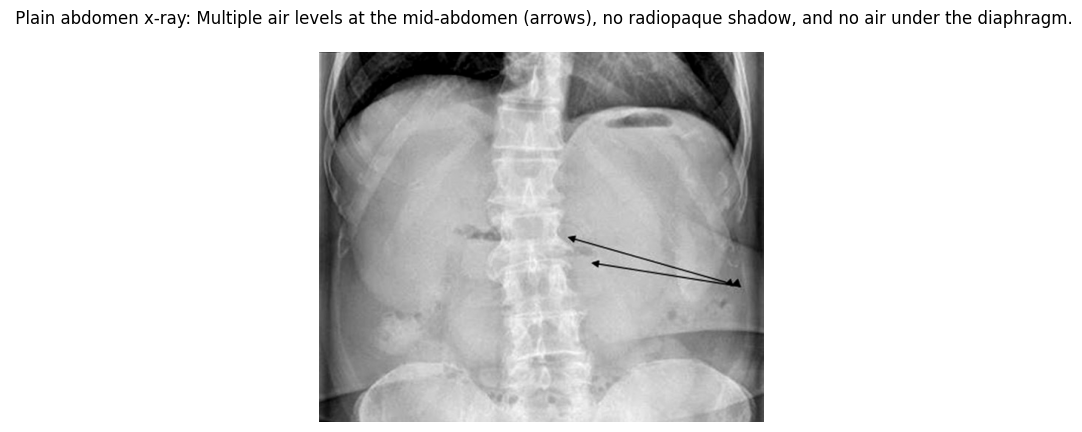

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

def show_sample_xray(xray_data):
    """Displays a sample X-ray image with its caption."""
    if not xray_data:
        print("No X-ray images found!")
        return

    img_path, caption = xray_data[0]
    img = Image.open(img_path)

    plt.imshow(img, cmap="gray")  # Medical images are usually grayscale
    plt.axis("off")
    plt.title(caption)
    plt.show()

# Show a sample X-ray image
show_sample_xray(xray_data)


In [ ]:
import os
import pandas as pd

# Define the dataset folder
xray_dataset_path = "/content/working_new/train/xray_dataset_NEW"
captions_file = os.path.join(xray_dataset_path, "captions.txt")

# Read the captions file
captions = pd.read_csv(captions_file, sep="\t", names=["image_name", "caption"])

# Add full image paths
captions["image_path"] = captions["image_name"].apply(lambda x: os.path.join(xray_dataset_path, x))

# Show first few rows
captions.head()


,image_name,caption,image_path
0,PMC4917066_amjcaserep-17-301-g001.jpg,Plain abdomen x-ray: Multiple air levels at t...,/content/working_new/train/xray_dataset_NEW/PM...
1,PMC5350332_CRIPE2017-6969787.003.jpg,AP pelvis X-ray obtained 6 weeks from initial...,/content/working_new/train/xray_dataset_NEW/PM...
2,PMC4891922_12891_2016_1099_Fig3_HTML.jpg,X-ray control of calcaneus drilling,/content/working_new/train/xray_dataset_NEW/PM...
3,PMC4239440_PAMJ-18-217-g001.jpg,Free air beneath the diaphragm at abdominal x...,/content/working_new/train/xray_dataset_NEW/PM...
4,PMC4546967_CRIOR2015-301949.003.jpg,X-ray arthrogram showing mild contrast tracki...,/content/working_new/train/xray_dataset_NEW/PM...


In [ ]:
len(captions)

5417

## `load Xception Model`

In [ ]:
from tensorflow.keras.applications import Xception

In [ ]:
#load Xception model
xception= Xception()
model = Model(inputs=xception.inputs,outputs=xception.layers[-2].output)
print(model.summary())

91884032/91884032 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 299, 299, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv1 (Conv2D)     │ (None, 149, 149, 32)   │            864 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv1_bn           │ (None, 149, 149, 32)   │            128 │ block1_conv1[0][0]     │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv1_act          │ (None, 149, 149, 32)   │              0 │ block1_conv1_bn[0][0]  │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv2 (Conv2D)     │ (None, 147, 147, 64)   │         18,432 │ block1_conv1_act[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv2_bn           │ (None, 147, 147, 64)   │            256 │ block1_conv2[0][0]     │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv2_act          │ (None, 147, 147, 64)   │              0 │ block1_conv2_bn[0][0]  │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_sepconv1           │ (None, 147, 147, 128)  │          8,768 │ block1_conv2_act[0][0] │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_sepconv1_bn        │ (None, 147, 147, 128)  │            512 │ block2_sepconv1[0][0]  │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_sepconv2_act       │ (None, 147, 147, 128)  │              0 │ block2_sepconv1_bn[0]… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_sepconv2           │ (None, 147, 147, 128)  │         17,536 │ block2_sepconv2_act[0… │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_sepconv2_bn        │ (None, 147, 147, 128)  │            512 │ block2_sepconv2[0][0]  │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 74, 74, 128)    │          8,192 │ block1_conv2_act[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_pool               │ (None, 74, 74, 128)    │              0 │ block2_sepconv2_bn[0]… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization  

 Total params: 20,861,480 (79.58 MB)

 Trainable params: 20,806,952 (79.37 MB)

 Non-trainable params: 54,528 (213.00 KB)

None


## `PreProssing in images and Extract features for images`

In [ ]:
image_paths='/content/working_new/train/xray_dataset_NEW'

In [ ]:
def show_image_size(image_path):
    """Displays the size of an image before and after resizing."""
    with Image.open(image_path) as img:
        print(f"Original size: {img.size}")  # Print original size
        plt.imshow(img, cmap="gray")
        plt.axis("off")
        plt.title(f"Original Size: {img.size}")
        plt.show()


Original size: (600, 499)


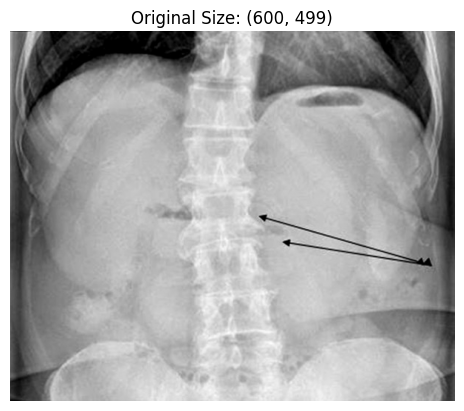

Resized size: (256, 256)


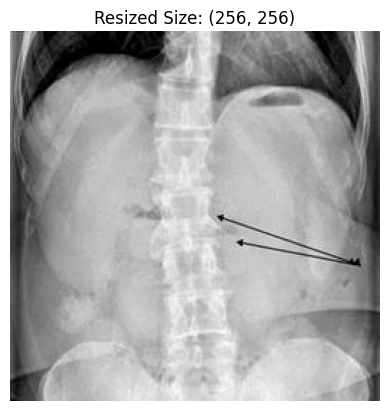

Resized images saved to: /content/working/train/xray_dataset_resized


In [ ]:

def resize_images_and_show(image_paths, output_folder, output_size=(256, 256)):
    """
    Resizes images, saves them to a new folder, and displays before/after sizes.

    Args:
        image_paths (list): List of image file paths.
        output_folder (str): Folder to save resized images.
        output_size (tuple): Target image size (width, height).
    """
    os.makedirs(output_folder, exist_ok=True)

    for img_path in image_paths:
        if os.path.exists(img_path):
            try:
                with Image.open(img_path) as img:
                    # Show original size
                    show_image_size(img_path)

                    # Resize the image
                    img = img.resize(output_size, Image.LANCZOS)

                    # Save to new folder
                    new_img_path = os.path.join(output_folder, os.path.basename(img_path))
                    img.save(new_img_path)

                    # Show new size
                    with Image.open(new_img_path) as resized_img:
                        print(f"Resized size: {resized_img.size}")  # Print new size
                        plt.imshow(resized_img, cmap="gray")
                        plt.axis("off")
                        plt.title(f"Resized Size: {resized_img.size}")
                        plt.show()

                    # Stop after one sample for display (remove this to show all)
                    break

            except Exception as e:
                print(f"Error processing {img_path}: {e}")

# Define the folder for resized images
resized_folder = os.path.join(OUTPUT_DIR, "train", "xray_dataset_resized")

# Apply resizing and show before/after sizes
resize_images_and_show([img_path for img_path, _ in xray_data], resized_folder)

print(f"Resized images saved to: {resized_folder}")


In [ ]:
OUTPUT_DIR_OF_IMAGES='/content/working_new/train'

In [ ]:
import os
import numpy as np
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.inception_v3 import preprocess_input
from PIL import UnidentifiedImageError  # Import error handling

feature_image = {}
dir_img = os.path.join(OUTPUT_DIR_OF_IMAGES, 'xray_dataset_NEW')

for img_name in tqdm(os.listdir(dir_img)):
    img_path = os.path.join(dir_img, img_name)

    try:
        # Load image and resize
        image = load_img(img_path, target_size=(299, 299))

        # Convert image to array
        img_array = img_to_array(image)

        # Reshape for model input
        img_reshape = np.expand_dims(img_array, axis=0)

        # Preprocess input
        img_pre = preprocess_input(img_reshape)

        # Extract features
        feature = model.predict(img_pre, verbose=0)

        # Save features using image ID
        img_id = os.path.splitext(img_name)[0]
        feature_image[img_id] = feature

    except UnidentifiedImageError:
        print(f"Skipping corrupt image: {img_name}")
    except Exception as e:
        print(f"Error processing {img_name}: {e}")

print("Feature extraction complete!")


NameError: name 'OUTPUT_DIR_OF_IMAGES' is not defined

In [ ]:
pickle.dump(feature_image,open(os.path.join(OUTPUT_DIR,'Feature_image.pkl'),'wb'))

## `load caption`

In [ ]:
captions['caption'][100]

' Chest X-ray performed after transplantation. Two drains inserted in right pleural cavity and catheter in right carotid internal vein are visible'

In [ ]:
len(captions)

5417

In [ ]:
import pandas as pd
from tqdm import tqdm

def extract_captions(df):
    """
    Extracts image captions from a DataFrame and organizes them by image ID.

    Args:
        df (pd.DataFrame): DataFrame containing image metadata.

    Returns:
        dict: Dictionary where keys are image IDs and values are lists of captions.
    """
    captions_img = {}

    # Iterate over rows in the DataFrame
    for _, row in tqdm(df.iterrows(), total=len(df)):
        try:
            img_id = row["image_name"].split('.')[0]  # Remove file extension
            caption = row["caption"]  # Extract caption text

            # Store in dictionary
            if img_id not in captions_img:
                captions_img[img_id] = []
            captions_img[img_id].append(caption)

        except Exception as e:
            print(f"Skipping row due to error: {e}")

    return captions_img





# Extract captions
captions_dict = extract_captions(captions)

# Show first 5 entries
for img_id, captions in list(captions_dict.items())[:5]:
    print(f"Image ID: {img_id}\nCaptions: {captions}\n{'-'*80}")


100%|██████████| 5417/5417 [00:00<00:00, 26915.26it/s]

Image ID: PMC4917066_amjcaserep-17-301-g001
Captions: [' Plain abdomen x-ray: Multiple air levels at the mid-abdomen (arrows), no radiopaque shadow, and no air under the diaphragm.']
--------------------------------------------------------------------------------
Image ID: PMC5350332_CRIPE2017-6969787
Captions: [' AP pelvis X-ray obtained 6 weeks from initial presentation which shows early femoral head collapse.', ' AP pelvis X-ray showing avascular changes of subchondral cystic lucency without evidence of femoral head collapse.', ' Frog leg lateral X-ray of bilateral hips again showing avascular changes with characteristic “crescent sign” of osteonecrosis to right femoral head.', ' AP pelvis X-ray obtained 12 weeks from initial presentation with progressive flattening of femoral epiphysis indicative of segmental collapse seen in non-Perthes osteonecrosis.']
--------------------------------------------------------------------------------
Image ID: PMC4891922_12891_2016_1099_Fig3_HTML
C

In [ ]:
import nltk

# Download required resources
nltk.download("punkt")       # Tokenizer
nltk.download("stopwords")   # Stop words list
nltk.download("wordnet")     # WordNet dictionary (Fixes the error)
nltk.download("averaged_perceptron_tagger")  # POS tagging (needed for correct lemmatization

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [ ]:
import nltk

# Set an alternate NLTK data directory (your home folder)
nltk.data.path.append('/kaggle/working/')

# Download stopwords and WordNet to this location
nltk.download('stopwords', download_dir='/kaggle/working/')
nltk.download('wordnet', download_dir='/kaggle/working/')


[nltk_data] Downloading package stopwords to /kaggle/working/...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /kaggle/working/...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


# Initialize stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean(captions_img):
    """
    Cleans and normalizes captions by lowercasing, removing non-alphabetic characters,
    removing stopwords, lemmatizing, and adding start/end tokens.

    Args:
        captions_img (dict): Dictionary where keys are image IDs and values are lists of captions.

    Returns:
        dict: Cleaned captions dictionary.
    """
    for key, captions in captions_img.items():
        for i in range(len(captions)):
            caption = captions[i]

            # Lowercase the text
            caption = caption.lower()

            # Remove non-alphabet characters (except spaces)
            caption = re.sub(r'[^a-z\s]', '', caption)

            # Remove extra spaces
            caption = re.sub(r'\s+', ' ', caption).strip()

            # Tokenize words
            words = caption.split()

            # Remove stopwords & lemmatize
            words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

            # Reconstruct caption with start/end tokens
            caption = f"startseq {' '.join(words)} endseq"

            # Update the list
            captions[i] = caption

    return captions_img

# Example Usage
cleaned_captions = clean(captions_dict)

# Show first 5 cleaned captions
for img_id, captions in list(cleaned_captions.items())[:5]:
    print(f"Image ID: {img_id}\nCleaned Captions: {captions}\n{'-'*80}")


Image ID: PMC4917066_amjcaserep-17-301-g001
Cleaned Captions: ['startseq plain abdomen xray multiple air level midabdomen arrow radiopaque shadow air diaphragm endseq']
--------------------------------------------------------------------------------
Image ID: PMC5350332_CRIPE2017-6969787
Cleaned Captions: ['startseq ap pelvis xray obtained week initial presentation show early femoral head collapse endseq', 'startseq ap pelvis xray showing avascular change subchondral cystic lucency without evidence femoral head collapse endseq', 'startseq frog leg lateral xray bilateral hip showing avascular change characteristic crescent sign osteonecrosis right femoral head endseq', 'startseq ap pelvis xray obtained week initial presentation progressive flattening femoral epiphysis indicative segmental collapse seen nonperthes osteonecrosis endseq']
--------------------------------------------------------------------------------
Image ID: PMC4891922_12891_2016_1099_Fig3_HTML
Cleaned Captions: ['start

In [ ]:
cleaned_captions['PMC5350332_CRIPE2017-6969787']

['startseq ap pelvis xray obtained week initial presentation show early femoral head collapse endseq',
 'startseq ap pelvis xray showing avascular change subchondral cystic lucency without evidence femoral head collapse endseq',
 'startseq frog leg lateral xray bilateral hip showing avascular change characteristic crescent sign osteonecrosis right femoral head endseq',
 'startseq ap pelvis xray obtained week initial presentation progressive flattening femoral epiphysis indicative segmental collapse seen nonperthes osteonecrosis endseq']

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
# Step 1: Prepare captions data for tokenization

all_captions = []
for captions in cleaned_captions.values():
    all_captions.extend(captions)




In [ ]:
all_captions[:10]

['startseq plain abdomen xray multiple air level midabdomen arrow radiopaque shadow air diaphragm endseq',
 'startseq ap pelvis xray obtained week initial presentation show early femoral head collapse endseq',
 'startseq ap pelvis xray showing avascular change subchondral cystic lucency without evidence femoral head collapse endseq',
 'startseq frog leg lateral xray bilateral hip showing avascular change characteristic crescent sign osteonecrosis right femoral head endseq',
 'startseq ap pelvis xray obtained week initial presentation progressive flattening femoral epiphysis indicative segmental collapse seen nonperthes osteonecrosis endseq',
 'startseq xray control calcaneus drilling endseq',
 'startseq free air beneath diaphragm abdominal xray film endseq',
 'startseq xray arthrogram showing mild contrast tracking along proximal lateral aspect femoral component endseq',
 'startseq pelvic xray hour ct showed gastric band connecting tube lower pelvis endseq',
 'startseq chest xray confi

In [ ]:
# Step 2: Tokenize captions
tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)
vcab_size = len(tokenizer.word_index)+1

In [ ]:
vcab_size

5839

In [ ]:
# Tokenizer
tokenizer = Tokenizer(num_words=vcab_size, oov_token="<UNK>")
tokenizer.fit_on_texts([" ".join(captions) for captions in cleaned_captions.values()])

In [ ]:
# Convert text to sequences
sequences = tokenizer.texts_to_sequences([" ".join(captions) for captions in cleaned_captions.values()])


In [ ]:
# Step 4: Find max sequence length
max_length = max(len(seq) for seq in sequences)

In [ ]:
max_length

136

In [ ]:
# Pad sequences
padded_sequences = pad_sequences(sequences, maxlen=max_length, padding="post")


In [ ]:
# Step 6: Create Embedding Layer
embedding_dim = 300  # Size of word vectors (e.g., 100, 200, 300)
embedding_layer = Embedding(input_dim=vcab_size, output_dim=embedding_dim, input_length=max_length)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
print(f"✅ Embedding layer created with vocab size {vcab_size} and max length {max_length}.")


✅ Embedding layer created with vocab size 5839 and max length 136.


In [ ]:
# Convert to numpy array (dummy embeddings for now)
embedding_matrix = np.random.rand(vcab_size, embedding_dim)

In [ ]:
# Save the tokenizer
tokenizer_path = "tokenizer.pkl"
with open(tokenizer_path, "wb") as f:
    pickle.dump(tokenizer, f)

# Save the embedding matrix
embedding_matrix_path = "embedding_matrix.npy"
np.save(embedding_matrix_path, embedding_matrix)

print(f"Tokenizer saved to: {tokenizer_path}")
print(f"Embedding matrix saved to: {embedding_matrix_path}")


Tokenizer saved to: tokenizer.pkl
Embedding matrix saved to: embedding_matrix.npy


In [ ]:
# train test split

image_ids = list(captions_dict.keys())
split = int(len(image_ids)*0.95)
split

4962

In [ ]:
train = image_ids[ : split]
test = image_ids[split : ]

In [ ]:
len(train)

4962

In [ ]:
len(test)

262

## `test1`

In [ ]:
import pickle
import numpy as np

# Split dataset (95% Train, 5% Test)
image_ids = list(captions_dict.keys())
split = int(len(image_ids) * 0.95)

train_ids = image_ids[:split]
test_ids = image_ids[split:]

print(f"Training Samples: {len(train_ids)}, Testing Samples: {len(test_ids)}")


Training Samples: 4962, Testing Samples: 262


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load tokenizer
with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

# Load embedding matrix
embedding_matrix = np.load("embedding_matrix.npy")

# Get vocabulary size and max sequence length
vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(seq) for seq in tokenizer.texts_to_sequences([" ".join(captions) for captions in captions_dict.values()]))

print(f"Vocabulary Size: {vocab_size}, Max Length: {max_length}")


Vocabulary Size: 5840, Max Length: 136


In [ ]:
# Convert captions to sequences
train_sequences = tokenizer.texts_to_sequences([" ".join(captions_dict[i]) for i in train_ids])
test_sequences = tokenizer.texts_to_sequences([" ".join(captions_dict[i]) for i in test_ids])

# Pad sequences
train_padded = pad_sequences(train_sequences, maxlen=max_length, padding="post")
test_padded = pad_sequences(test_sequences, maxlen=max_length, padding="post")

print(f"Train Shape: {train_padded.shape}, Test Shape: {test_padded.shape}")


Train Shape: (4962, 136), Test Shape: (262, 136)


In [ ]:
image_path='/content/working_new/train/xray_dataset_NEW'

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Define Image Size for Model
IMG_SIZE = (256, 256)

def preprocess_image(image_path):
    """Load and preprocess an image if it exists."""
    if not os.path.exists(image_path):
        print(f"⚠️ Warning: File not found: {image_path}")
        return None  # Skip missing files
    img = load_img(image_path, target_size=IMG_SIZE)  # Resize image
    img = img_to_array(img) / 255.0  # Normalize pixel values
    return img

# Define X-ray image directory
xray_dir = "/content/working_new/train/xray_dataset_NEW"

# Get all image filenames (assuming they are JPG/PNG files)
image_filenames = [f for f in os.listdir(xray_dir) if f.endswith((".jpg", ".png", ".jpeg"))]

# Load and preprocess all X-ray images
xray_images = [preprocess_image(os.path.join(xray_dir, img)) for img in image_filenames]

# Remove None values (skipping missing files)
xray_images = np.array([img for img in xray_images if img is not None])

print(f"✅ Loaded {len(xray_images)} X-ray images")
print(f"📏 Image Data Shape: {xray_images.shape}")


✅ Loaded 5417 X-ray images
📏 Image Data Shape: (5417, 256, 256, 3)


In [ ]:
from tensorflow.keras.layers import Layer, Dense, Softmax

class CrossAttention(Layer):
    def __init__(self, embed_dim):
        super(CrossAttention, self).__init__()
        self.query_dense = Dense(embed_dim)
        self.key_dense = Dense(embed_dim)
        self.value_dense = Dense(embed_dim)
        self.softmax = Softmax(axis=-1)

    def call(self, query, key, value):
        query = self.query_dense(query)
        key = self.key_dense(key)
        value = self.value_dense(value)

        attention_scores = tf.matmul(query, key, transpose_b=True)
        attention_weights = self.softmax(attention_scores)
        attention_output = tf.matmul(attention_weights, value)

        return attention_output


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2DTranspose, Reshape, Flatten

# Encoder for text
def text_encoder(vocab_size, embedding_dim, max_length):
    inputs = Input(shape=(max_length,))
    embedding = Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length)(inputs)
    encoded_text = Flatten()(embedding)
    model = Model(inputs, encoded_text, name="TextEncoder")
    return model

# Generator with Cross-Attention
def attn_gan_generator():
    text_input = Input(shape=(max_length,))
    image_input = Input(shape=(256, 256, 3))

    # Text encoder
    text_encoder_model = text_encoder(vocab_size, embedding_dim, max_length)
    text_features = text_encoder_model(text_input)

    # Apply Cross-Attention
    attention = CrossAttention(embed_dim=256)(text_features, text_features, text_features)

    # Upsample Image
    x = Conv2DTranspose(128, (3,3), activation='relu', padding='same')(image_input)
    x = Conv2DTranspose(64, (3,3), activation='relu', padding='same')(x)
    x = Conv2DTranspose(3, (3,3), activation='sigmoid', padding='same')(x)

    generator = Model([text_input, image_input], x, name="AttnGAN_Generator")
    return generator

generator = attn_gan_generator()
generator.summary()


Model: "AttnGAN_Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 256, 256, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_transpose          │ (None, 256, 256, 128)  │          3,584 │ input_layer_1[0][0]    │
│ (Conv2DTranspose)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_transpose_1        │ (None, 256, 256, 64)   │         73,792 │ conv2d_transpose[0][0] │
│ (Conv2DTranspose)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer (InputLayer)  │ (None, 136)            │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_transpose_2        │ (None, 256, 256, 3)    │          1,731 │ conv2d_transpose_1[0]… │
│ (Conv2DTranspose)         │                        │                │                        │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 79,107 (309.01 KB)

 Trainable params: 79,107 (309.01 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.layers import Conv2D, LeakyReLU

def attn_gan_discriminator():
    image_input = Input(shape=(256, 256, 3))

    x = Conv2D(64, (3,3), strides=(2,2), padding='same')(image_input)
    x = LeakyReLU()(x)

    x = Conv2D(128, (3,3), strides=(2,2), padding='same')(x)
    x = LeakyReLU()(x)

    x = Flatten()(x)
    output = Dense(1, activation='sigmoid')(x)

    discriminator = Model(image_input, output, name="AttnGAN_Discriminator")
    return discriminator

discriminator = attn_gan_discriminator()
discriminator.summary()


Model: "AttnGAN_Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 128, 128, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu (LeakyReLU)              │ (None, 128, 128, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_1 (LeakyReLU)            │ (None, 64, 64, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 524288)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │         524,289 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 599,937 (2.29 MB)

 Trainable params: 599,937 (2.29 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
train_ids = image_ids[:split]  # Training data
test_ids = image_ids[split:]   # Testing data


In [ ]:
# Compile Models
generator.compile(optimizer=Adam(0.0002, 0.5), loss="binary_crossentropy")
discriminator.compile(optimizer=Adam(0.0002, 0.5), loss="binary_crossentropy")

# Create GAN Model
discriminator.trainable = False
text_input = Input(shape=(max_length,))
image_input = Input(shape=(256, 256, 3))
generated_image = generator([text_input, image_input])
gan_output = discriminator(generated_image)
gan_model = Model([text_input, image_input], gan_output)
gan_model.compile(loss="binary_crossentropy", optimizer=Adam(0.0002, 0.5))

# Training Loop
EPOCHS = 5
BATCH_SIZE = 32

for epoch in range(EPOCHS):
    for i in range(0, len(train_ids), BATCH_SIZE):
        batch_images = np.array([xray_images[i % len(xray_images)] for i in range(i, i + BATCH_SIZE)])
        batch_captions = np.array([train_padded[i % len(train_padded)] for i in range(i, i + BATCH_SIZE)])

        # Generate Fake Images
        generated_images = generator.predict([batch_captions, batch_images])

        # Train Discriminator
        real_labels = np.ones((BATCH_SIZE, 1)) * 0.9
        fake_labels = np.zeros((BATCH_SIZE, 1)) + 0.1
        d_loss_real = discriminator.train_on_batch(batch_images, real_labels)
        d_loss_fake = discriminator.train_on_batch(generated_images, fake_labels)
        d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

        # Train Generator
        g_loss = gan_model.train_on_batch([batch_captions, batch_images], real_labels)

    print(f"Epoch {epoch+1}/{EPOCHS} - D Loss: {d_loss:.4f} - G Loss: {g_loss:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py:82: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
# Save trained models
generator.save("generator_model.h5")
discriminator.save("discriminator_model.h5")
gan_model.save("gan_model.h5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step


Exception ignored in: <function _xla_gc_callback at 0x7dad30546520>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/jax/_src/lib/__init__.py", line 96, in _xla_gc_callback
    def _xla_gc_callback(*args):
    
KeyboardInterrupt: 


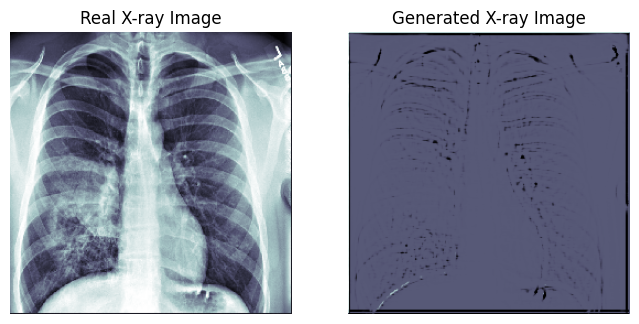

✅ Discriminator thinks this is a REAL X-ray.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Load trained models
generator = tf.keras.models.load_model("generator_model.h5")
discriminator = tf.keras.models.load_model("discriminator_model.h5")

# Select a random test caption
random_index = np.random.randint(0, len(test_ids))
test_caption = test_padded[random_index]  # Shape: (max_length,)
test_image = xray_images[random_index]  # Shape: (256, 256, 3) or (256, 256)

# ✅ Ensure input image has 3 channels
if len(test_image.shape) == 2:  # Convert grayscale to RGB
    test_image = np.stack([test_image] * 3, axis=-1)  # Shape: (256, 256, 3)

# ✅ Ensure correct shape for model input
test_caption = np.expand_dims(test_caption, axis=0)  # Shape: (1, max_length)
test_image = np.expand_dims(test_image, axis=0)  # Shape: (1, 256, 256, 3)

# Generate Fake X-ray Image
generated_image = generator.predict([test_caption, test_image])

# ✅ Convert generated image back to valid range (0-1)
generated_image = np.clip(generated_image[0], 0, 1)

# ✅ Convert grayscale generated image to 3 channels for the discriminator
if generated_image.shape[-1] == 1:  # If grayscale (256, 256, 1)
    generated_image = np.repeat(generated_image, 3, axis=-1)  # Convert to (256, 256, 3)

# ✅ Ensure discriminator input has correct shape
generated_image_input = np.expand_dims(generated_image, axis=0)  # Shape: (1, 256, 256, 3)

# Pass the generated image to the discriminator
prediction = discriminator.predict(generated_image_input)

# Interpret the result
if prediction[0][0] > 0.5:
    result_text = "✅ Discriminator thinks this is a REAL X-ray."
else:
    result_text = "❌ Discriminator thinks this is a FAKE X-ray."

# 🎨 Convert images to grayscale for "bone" colormap
test_image_gray = np.mean(test_image[0], axis=-1)  # Shape: (256, 256)
generated_image_gray = np.mean(generated_image, axis=-1)  # Shape: (256, 256)

# Show Results with X-ray Colormap
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(test_image_gray, cmap="bone")  # X-ray effect
plt.title("Real X-ray Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(generated_image_gray, cmap="bone")  # X-ray effect
plt.title("Generated X-ray Image")
plt.axis("off")

plt.show()

# Print Discriminator's decision
print(result_text)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def compare_real_vs_fake(caption, tokenizer, generator_model, real_images, real_captions, discriminator_model=None):
    """
    Compare a real X-ray image with a generated (fake) one for the same caption.

    Args:
        caption (str): The text description for which we generate an image.
        tokenizer: The trained tokenizer for text preprocessing.
        generator_model: The trained generator model.
        real_images (numpy.ndarray): Array of real X-ray images.
        real_captions (numpy.ndarray): Tokenized real captions.
        discriminator_model: The trained discriminator model (optional).

    Returns:
        None (Displays the comparison plot)
    """
    # ✅ Step 1: Preprocess Text Input
    processed_caption = preprocess_text(caption, tokenizer)

    # ✅ Step 2: Select the Closest Real Image
    random_index = np.random.randint(0, len(real_captions))
    real_image = real_images[random_index]  # Shape: (256, 256, 3) or (256, 256)

    # Convert grayscale to 3-channel format if needed
    if len(real_image.shape) == 2:
        real_image = np.stack([real_image] * 3, axis=-1)

    # Add batch dimension
    real_image = np.expand_dims(real_image, axis=0)

    # ✅ Step 3: Generate Fake Image
    generated_image = generator_model.predict([processed_caption, real_image])
    generated_image = np.clip(generated_image[0], 0, 1)

    # Convert grayscale fake image to 3-channel format
    if generated_image.shape[-1] == 1:
        generated_image = np.repeat(generated_image, 3, axis=-1)

    # ✅ Step 4: Evaluate with Discriminator (Optional)
    real_score, fake_score = None, None
    if discriminator_model:
        real_score = discriminator_model.predict(real_image)[0][0]
        fake_score = discriminator_model.predict(np.expand_dims(generated_image, axis=0))[0][0]

    # ✅ Step 5: Display the Comparison
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(np.mean(real_image[0], axis=-1), cmap="bone")
    plt.title(f"🩻 Real X-ray\nDiscriminator: {real_score:.4f}" if real_score else "🩻 Real X-ray")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(np.mean(generated_image, axis=-1), cmap="bone")
    plt.title(f"🖼️ Generated X-ray\nDiscriminator: {fake_score:.4f}" if fake_score else "🖼️ Generated X-ray")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # ✅ Print Discriminator's Decision
    if discriminator_model:
        print(f"✅ Real Image Score: {real_score:.4f}")
        print(f"❌ Generated Image Score: {fake_score:.4f}")



In [ ]:
# Load trained models
generator = tf.keras.models.load_model("generator_model.h5")
discriminator = tf.keras.models.load_model("discriminator_model.h5")

# Define a sample caption
sample_caption = "Hypertensive retinopathy with vascular narrowing"

# Run the comparison
compare_real_vs_fake(sample_caption, tokenizer, generator, xray_images, train_padded, discriminator)


ValueError: Input 0 of layer "AttnGAN_Generator" is incompatible with the layer: expected shape=(None, 136), found shape=(1, 20)

# test improve

In [ ]:
import os
import pickle
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Embedding, Flatten, Dense, Conv2DTranspose, BatchNormalization,
                                     ReLU, Conv2D, LeakyReLU, Softmax, SpectralNormalization)
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [ ]:
# Convert captions to sequences
sequences = tokenizer.texts_to_sequences(all_captions)

# Get vocabulary size and max length
vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(seq) for seq in sequences)

# Pad sequences
captions_padded = pad_sequences(sequences, maxlen=max_length, padding="post")

# Save embedding matrix (random initialization for now)
embedding_matrix = np.random.rand(vocab_size, embedding_dim)
np.save("embedding_matrix.npy", embedding_matrix)

# Load tokenizer and embedding matrix
with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)
embedding_matrix = np.load("embedding_matrix.npy")

In [ ]:
# Define parameters
vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(seq) for seq in tokenizer.texts_to_sequences([" ".join(c) for c in captions_dict.values()]))
IMG_SIZE = (256, 256)
BATCH_SIZE = 32
EPOCHS = 5

In [ ]:
max_length

136

In [ ]:
# Load images
def preprocess_image(image_path):
    if not os.path.exists(image_path):
        print(f"⚠️ Warning: File not found: {image_path}")
        return None
    img = load_img(image_path, target_size=IMG_SIZE)
    img = img_to_array(img) / 255.0
    return img

xray_dir = "/content/working_new/train/xray_dataset_NEW"
image_filenames = [f for f in os.listdir(xray_dir) if f.endswith((".jpg", ".png", ".jpeg"))]
xray_images = [preprocess_image(os.path.join(xray_dir, img)) for img in image_filenames]
xray_images = np.array([img for img in xray_images if img is not None])

In [ ]:
# Cross-Attention Layer
class CrossAttention(tf.keras.layers.Layer):
    def __init__(self, embed_dim):
        super(CrossAttention, self).__init__()
        self.query_dense = Dense(embed_dim)
        self.key_dense = Dense(embed_dim)
        self.value_dense = Dense(embed_dim)
        self.softmax = Softmax(axis=-1)

    def call(self, query, key, value):
        query = self.query_dense(query)
        key = self.key_dense(key)
        value = self.value_dense(value)
        attention_scores = tf.matmul(query, key, transpose_b=True)
        attention_weights = self.softmax(attention_scores)
        return tf.matmul(attention_weights, value)

In [ ]:
# Text Encoder
def text_encoder(vocab_size, embedding_dim, max_length):
    inputs = Input(shape=(max_length,))
    embedding = Embedding(input_dim=vocab_size, output_dim=embedding_dim, weights=[embedding_matrix], trainable=True)(inputs)
    encoded_text = Flatten()(embedding)
    return Model(inputs, encoded_text, name="TextEncoder")

# Generator
def attn_gan_generator():
    text_input = Input(shape=(max_length,))
    image_input = Input(shape=(256, 256, 3))

    text_encoder_model = text_encoder(vocab_size, embedding_dim, max_length)
    text_features = text_encoder_model(text_input)

    attention = CrossAttention(embed_dim=embedding_dim)(text_features, text_features, text_features)

    x = Conv2DTranspose(128, (3,3), activation='relu', padding='same')(image_input)
    x = Conv2DTranspose(64, (3,3), activation='relu', padding='same')(x)
    x = Conv2DTranspose(3, (3,3), activation='sigmoid', padding='same')(x)

    return Model([text_input, image_input], x, name="AttnGAN_Generator")


In [ ]:

# Discriminator
def attn_gan_discriminator():
    image_input = Input(shape=(256, 256, 3))
    x = Conv2D(64, (3,3), strides=(2,2), padding='same')(image_input)
    x = LeakyReLU()(x)
    x = Conv2D(128, (3,3), strides=(2,2), padding='same')(x)
    x = LeakyReLU()(x)
    x = Flatten()(x)
    output = Dense(1, activation='sigmoid')(x)
    return Model(image_input, output, name="AttnGAN_Discriminator")

# Compile and Train GAN
generator = attn_gan_generator()
discriminator = attn_gan_discriminator()

generator.compile(optimizer=Adam(0.0002, 0.5), loss="binary_crossentropy")
discriminator.compile(optimizer=Adam(0.0002, 0.5), loss="binary_crossentropy")

discriminator.trainable = False
text_input = Input(shape=(max_length,))
image_input = Input(shape=(256, 256, 3))
generated_image = generator([text_input, image_input])
gan_output = discriminator(generated_image)
gan_model = Model([text_input, image_input], gan_output)
gan_model.compile(loss="binary_crossentropy", optimizer=Adam(0.0002, 0.5))

In [ ]:
# Convert captions to sequences
captions_sequences = tokenizer.texts_to_sequences(all_captions)

# Save vocabulary size and max length
vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(seq) for seq in captions_sequences)

print(f"Vocabulary Size: {vocab_size}, Max Sequence Length: {max_length}")

# Pad sequences
train_padded = pad_sequences(captions_sequences, maxlen=max_length, padding="post")

# Save padded sequences
np.save("train_padded.npy", train_padded)

print(f"Padded Shape: {train_padded.shape}")

Vocabulary Size: 5840, Max Sequence Length: 136
Padded Shape: (5417, 136)


In [ ]:
# Load tokenizer
with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

# Load padded captions
train_padded = np.load("train_padded.npy")

# Load embedding matrix (ensure it exists or create one)
embedding_matrix = np.load("embedding_matrix.npy")  # Ensure this file exists

print(f"Loaded Train Captions Shape: {train_padded.shape}")


Loaded Train Captions Shape: (5417, 136)


In [ ]:
EPOCHS = 5
BATCH_SIZE = 32

for epoch in range(EPOCHS):
    for i in range(0, len(train_ids), BATCH_SIZE):
        batch_indices = np.arange(i, min(i + BATCH_SIZE, len(train_ids)))
        batch_size_actual = len(batch_indices)  # Handle last batch dynamically

        batch_images = np.array([xray_images[idx % len(xray_images)] for idx in batch_indices])
        batch_captions = np.array([train_padded[idx % len(train_padded)] for idx in batch_indices])

        # Generate Fake Images
        generated_images = generator.predict([batch_captions, batch_images])

        # Adjust labels to match batch size
        real_labels = np.ones((batch_size_actual, 1)) * 0.9  # Label smoothing
        fake_labels = np.zeros((batch_size_actual, 1)) + 0.1

        # Train Discriminator
        d_loss_real = discriminator.train_on_batch(batch_images, real_labels)
        d_loss_fake = discriminator.train_on_batch(generated_images, fake_labels)
        d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

        # Train Generator
        g_loss = gan_model.train_on_batch([batch_captions, batch_images], np.ones((batch_size_actual, 1)))

    print(f"Epoch {epoch+1}/{EPOCHS} - D Loss: {d_loss:.4f} - G Loss: {g_loss:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py:82: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
# Save trained models
# generator.save("generator_model1.h5")
discriminator.save("discriminator_model1.h5")
gan_model.save("gan_model1.h5")

In [ ]:
!pip install python-jose[cryptography]
import jose

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.3/149.3 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.1/77.1 kB 7.8 MB/s eta 0:00:00
  Attempting uninstall: pyasn1
    Found existing installation: pyasn1 0.6.1
    Uninstalling pyasn1-0.6.1:
      Successfully uninstalled pyasn1-0.6.1


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pickle
import json

# 1. Load your trained generator model
generator = tf.keras.models.load_model("generator_model1.h5", compile=False)

# 2. Load the tokenizer
with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

# 3. Load the Text Encoder (Used for embedding text to the correct shape)
text_encoder = tf.keras.models.load_model("text_encoder_model1.h5", compile=False)  # Load your trained TextEncoder model

# 4. Set the maximum sequence length (Replace with actual value)
max_length = 20  # Change this to your actual trained max_length value

# 5. Function to convert text to embedding
def text_to_embedding(text_description, tokenizer, max_length, text_encoder):
    """
    Convert text description into a 136-dimensional embedding using the trained text encoder.
    """
    # Tokenize and pad text
    sequence = tokenizer.texts_to_sequences([text_description])
    padded_sequence = pad_sequences(sequence, maxlen=max_length, padding="post")

    # Pass through the trained text encoder to get embedding (Shape: (1, 136))
    embedding_vector = text_encoder.predict(padded_sequence)

    return embedding_vector

# 6. Function to generate image from text
def generate_image_from_text(text_description, generator, tokenizer, max_length, text_encoder, noise_image=None):
    """
    Generate an image from a text description using a trained generator model.
    """
    # Convert text to embedding
    text_embedding = text_to_embedding(text_description, tokenizer, max_length, text_encoder)  # (1, 136)

    # Ensure correct noise input shape
    if noise_image is None:
        noise_image = np.random.normal(0, 1, (1, 256, 256, 1))  # Adjust shape based on training
    else:
        if len(noise_image.shape) == 3:  # Ensure batch dimension
            noise_image = np.expand_dims(noise_image, axis=0)

    # Generate the image
    generated_image = generator.predict([text_embedding, noise_image])

    # Ensure grayscale images are displayed correctly
    if generated_image.shape[-1] == 1:
        generated_image = generated_image.squeeze(axis=-1)

    # Normalize generated image (convert to range [0,1])
    generated_image = (generated_image - np.min(generated_image)) / (np.max(generated_image) - np.min(generated_image))

    return generated_image[0]  # Remove batch dimension

# 7. Function to visualize generated images
def visualize_generated_images(text_descriptions, generator, tokenizer, max_length, text_encoder):
    """
    Generate and visualize images for a list of text descriptions.
    """
    num_descriptions = len(text_descriptions)
    plt.figure(figsize=(10, 5 * num_descriptions))

    for i, description in enumerate(text_descriptions):
        # Generate image
        generated_image = generate_image_from_text(description, generator, tokenizer, max_length, text_encoder)

        # Display
        plt.subplot(num_descriptions, 1, i + 1)
        plt.imshow(generated_image, cmap="gray")  # Use grayscale colormap
        plt.title(f"Generated from: {description}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# 8. Define some test descriptions
test_descriptions = [
    "Normal chest X-ray with clear lung fields",
    "Chest X-ray showing cardiomegaly with pulmonary congestion",
    "X-ray revealing pneumonia in right lower lobe"
]

# 9. Generate and visualize images for testing
visualize_generated_images(test_descriptions, generator, tokenizer, max_length, text_encoder)


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'text_encoder_model1.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
import json

In [ ]:
# 1. Fix the max_length circular reference
max_length = max_length  # Replace with your actual value from training

# 2. Modify the noise image generation to match your training parameters
def generate_image_from_text(text_description, generator, tokenizer, max_length, noise_image=None):
    # Preprocess the text
    sequence = tokenizer.texts_to_sequences([text_description])
    padded_sequence = pad_sequences(sequence, maxlen=max_length, padding="post")

    # Create noise image with parameters matching your training
    if noise_image is None:
        # Try different noise distribution - uniform instead of normal
        noise_image = np.random.uniform(0, 1, (1, 256, 256, 3))
        # Or try grayscale if your X-rays are grayscale
        # noise_image = np.random.normal(0, 1, (1, 256, 256, 1))
    else:
        if len(noise_image.shape) == 3:
            noise_image = np.expand_dims(noise_image, axis=0)

    # Generate the image
    generated_image = generator.predict([padded_sequence, noise_image])

    # For grayscale output, you might need to adjust this:
    # If your model outputs grayscale images but displays in color
    if generated_image.shape[-1] == 1:
        generated_image = generated_image.squeeze(axis=-1)

    return np.clip(generated_image[0], 0, 1)  # Clip to valid range # Return the first (and only) image without batch dimension

# Example usage:
def visualize_generated_images(text_descriptions, generator, tokenizer, max_length):
    """
    Generate and visualize images for a list of text descriptions.

    Args:
        text_descriptions (list): List of text descriptions
        generator (Model): Trained generator model
        tokenizer: The tokenizer used during training
        max_length (int): Maximum sequence length used during training
    """
    import matplotlib.pyplot as plt

    num_descriptions = len(text_descriptions)
    plt.figure(figsize=(15, 5 * num_descriptions))

    for i, description in enumerate(text_descriptions):
        # Generate image
        generated_image = generate_image_from_text(description, generator, tokenizer, max_length)

        # Display
        plt.subplot(num_descriptions, 1, i + 1)
        plt.imshow(generated_image)
        plt.title(f"Generated from: {description}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# To save the model and generate example images for the deliverable
def save_model_and_examples(generator, discriminator, gan_model, tokenizer, max_length, example_descriptions):
    """
    Save the trained models and generate example images for the deliverable.

    Args:
        generator (Model): Trained generator model
        discriminator (Model): Trained discriminator model
        gan_model (Model): Trained GAN model
        tokenizer: The tokenizer used during training
        max_length (int): Maximum sequence length used during training
        example_descriptions (list): List of example text descriptions
    """
    # Save models
    generator.save("trained_generator.h5")
    discriminator.save("trained_discriminator.h5")
    gan_model.save("trained_gan_model.h5")

    # Save model artifacts
    model_info = {
        "max_length": max_length,
        "vocab_size": len(tokenizer.word_index) + 1,
        "embedding_dim": generator.get_layer('TextEncoder').output_shape[1]
    }

    with open("model_info.json", "w") as f:
        json.dump(model_info, f)

    # Generate and save example images
    plt.figure(figsize=(15, 5 * len(example_descriptions)))

    for i, description in enumerate(example_descriptions):
        # Generate image
        generated_image = generate_image_from_text(description, generator, tokenizer, max_length)

        # Save individual image
        plt.imsave(f"example_{i+1}.png", generated_image)

        # Display in combined figure
        plt.subplot(len(example_descriptions), 1, i + 1)
        plt.imshow(generated_image)
        plt.title(f"Generated from: {description}")
        plt.axis('off')

    # Save combined visualization
    plt.tight_layout()
    plt.savefig("example_generated_images.png")
    plt.close()

    print("Model and examples saved successfully!")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step


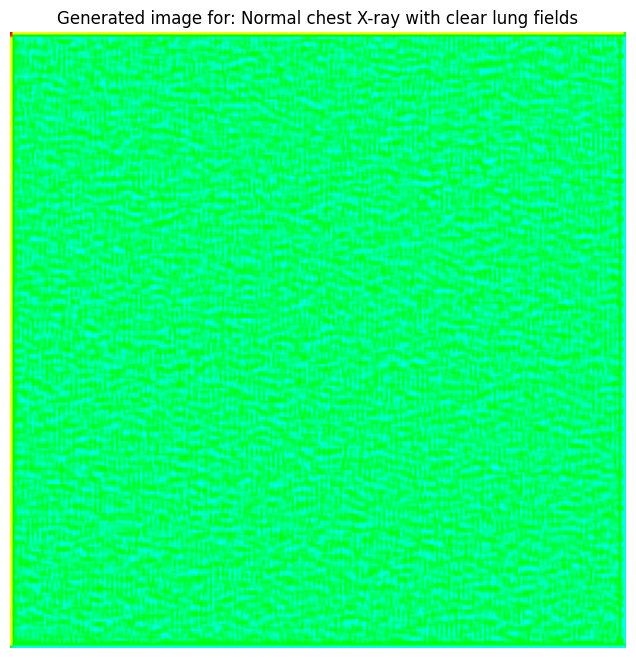

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


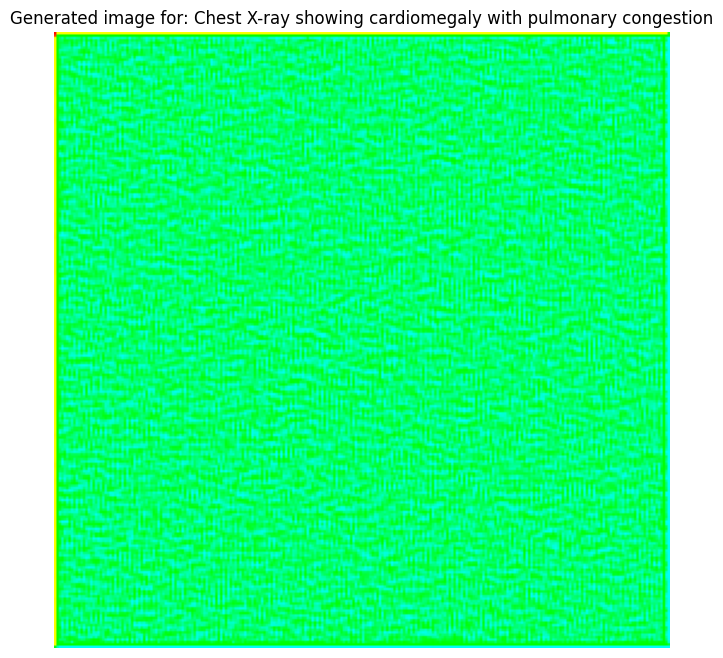

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


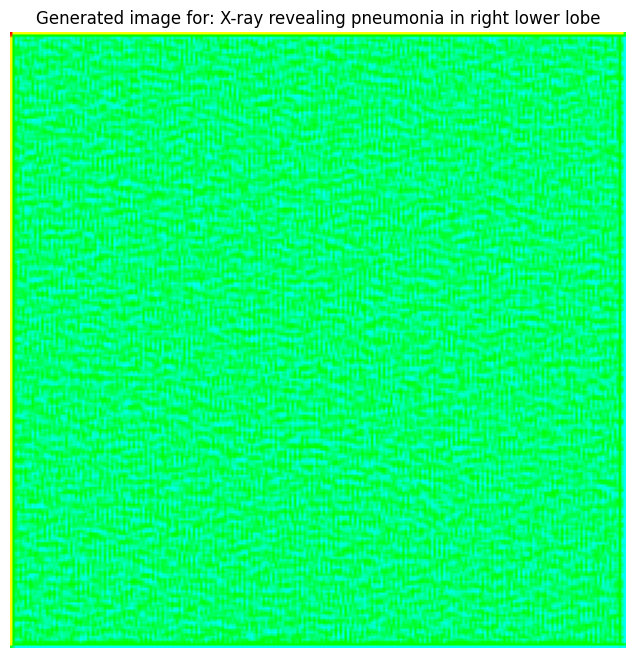

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pickle
import json

# 1. Load your trained models
generator = tf.keras.models.load_model("generator_model1.h5", compile=False)
# Or use your existing generator if you haven't saved it yet

# 2. Load the tokenizer
with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

# 3. Set the maximum sequence length
max_length = max_length  # Replace with your actual max_length value

# 4. Define some text descriptions to test
test_descriptions = [
    "Normal chest X-ray with clear lung fields",
    "Chest X-ray showing cardiomegaly with pulmonary congestion",
    "X-ray revealing pneumonia in right lower lobe"
]

# 5. Use the inference function to generate images
for description in test_descriptions:
    # Generate image from text
    generated_image = generate_image_from_text(
        description,
        generator,
        tokenizer,
        max_length
    )

    # Display the generated image
    plt.figure(figsize=(8, 8))
    plt.imshow(generated_image)
    plt.title(f"Generated image for: {description}")
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


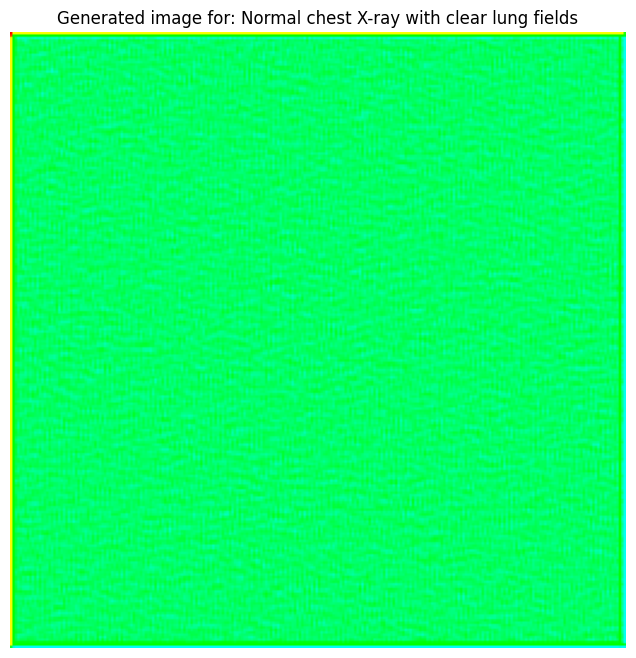

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


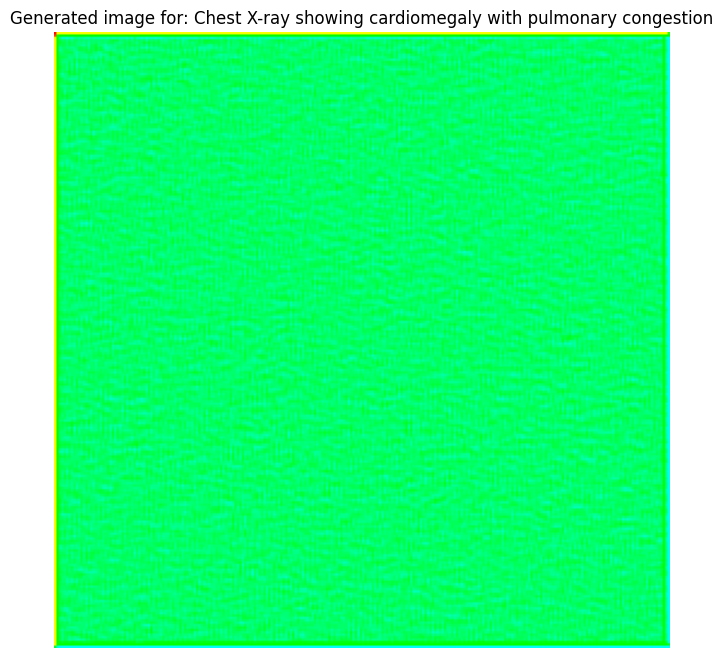

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


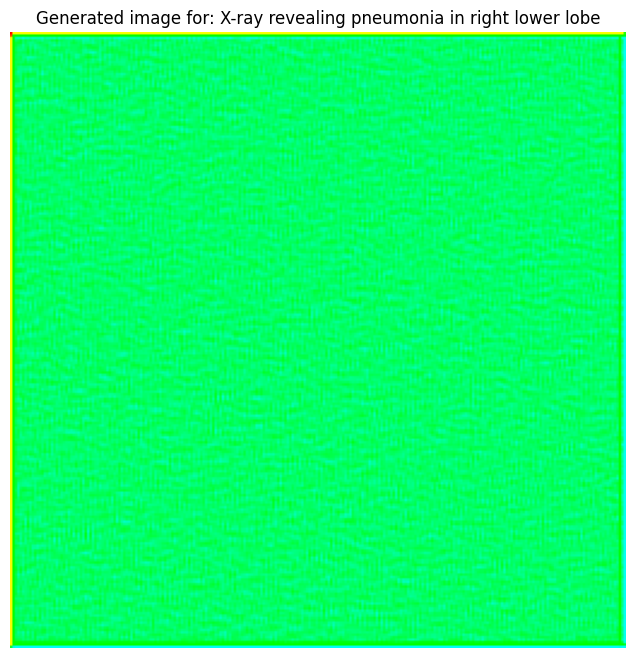

In [ ]:
# 5. Use the inference function to generate images
for description in test_descriptions:
    # Generate image from text
    generated_image = generate_image_from_text(
        description,
        generator,
        tokenizer,
        max_length
    )

    # Display the generated image
    plt.figure(figsize=(8, 8))
    plt.imshow(generated_image)
    plt.title(f"Generated image for: {description}")
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step


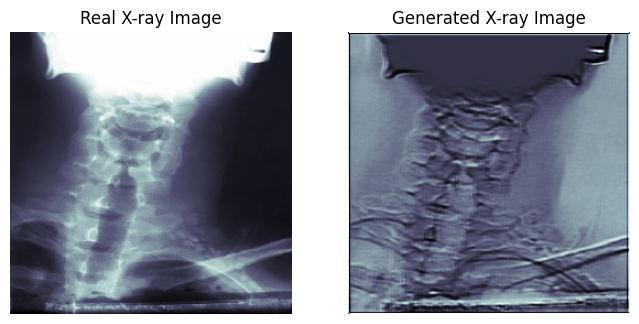

✅ Discriminator thinks this is a REAL X-ray.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Load trained models
generator = tf.keras.models.load_model("generator_model1.h5")
discriminator = tf.keras.models.load_model("discriminator_model1.h5")

# Select a random test caption
random_index = np.random.randint(0, len(test_ids))
test_caption = test_padded[random_index]  # Shape: (max_length,)
test_image = xray_images[random_index]  # Shape: (256, 256, 3) or (256, 256)

# ✅ Ensure input image has 3 channels
if len(test_image.shape) == 2:  # Convert grayscale to RGB
    test_image = np.stack([test_image] * 3, axis=-1)  # Shape: (256, 256, 3)

# ✅ Ensure correct shape for model input
test_caption = np.expand_dims(test_caption, axis=0)  # Shape: (1, max_length)
test_image = np.expand_dims(test_image, axis=0)  # Shape: (1, 256, 256, 3)

# Generate Fake X-ray Image
generated_image = generator.predict([test_caption, test_image])

# ✅ Convert generated image back to valid range (0-1)
generated_image = np.clip(generated_image[0], 0, 1)

# ✅ Convert grayscale generated image to 3 channels for the discriminator
if generated_image.shape[-1] == 1:  # If grayscale (256, 256, 1)
    generated_image = np.repeat(generated_image, 3, axis=-1)  # Convert to (256, 256, 3)

# ✅ Ensure discriminator input has correct shape
generated_image_input = np.expand_dims(generated_image, axis=0)  # Shape: (1, 256, 256, 3)

# Pass the generated image to the discriminator
prediction = discriminator.predict(generated_image_input)

# Interpret the result
if prediction[0][0] > 0.5:
    result_text = "✅ Discriminator thinks this is a REAL X-ray."
else:
    result_text = "❌ Discriminator thinks this is a FAKE X-ray."

# 🎨 Convert images to grayscale for "bone" colormap
test_image_gray = np.mean(test_image[0], axis=-1)  # Shape: (256, 256)
generated_image_gray = np.mean(generated_image, axis=-1)  # Shape: (256, 256)

# Show Results with X-ray Colormap
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(test_image_gray, cmap="bone")  # X-ray effect
plt.title("Real X-ray Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(generated_image_gray, cmap="bone")  # X-ray effect
plt.title("Generated X-ray Image")
plt.axis("off")

plt.show()

# Print Discriminator's decision
print(result_text)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step


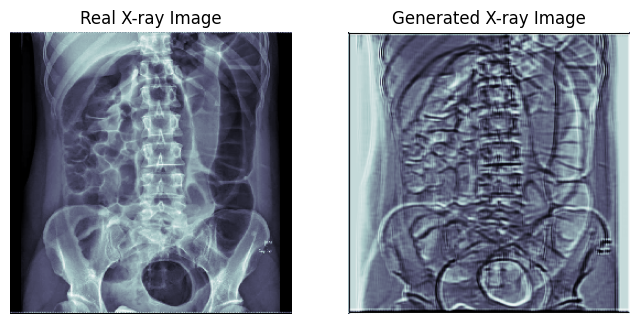

✅ Discriminator thinks this is a REAL X-ray.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Load trained models
generator = tf.keras.models.load_model("generator_model1.h5")
discriminator = tf.keras.models.load_model("discriminator_model1.h5")

# Select a random test caption
random_index = np.random.randint(0, len(test_ids))
test_caption = test_padded[random_index]  # Shape: (max_length,)
test_image = xray_images[random_index]  # Shape: (256, 256, 3) or (256, 256)

# ✅ Ensure input image has 3 channels
if len(test_image.shape) == 2:  # Convert grayscale to RGB
    test_image = np.stack([test_image] * 3, axis=-1)  # Shape: (256, 256, 3)

# ✅ Ensure correct shape for model input
test_caption = np.expand_dims(test_caption, axis=0)  # Shape: (1, max_length)
test_image = np.expand_dims(test_image, axis=0)  # Shape: (1, 256, 256, 3)

# Generate Fake X-ray Image
generated_image = generator.predict([test_caption, test_image])

# ✅ Convert generated image back to valid range (0-1)
generated_image = np.clip(generated_image[0], 0, 1)

# ✅ Convert grayscale generated image to 3 channels for the discriminator
if generated_image.shape[-1] == 1:  # If grayscale (256, 256, 1)
    generated_image = np.repeat(generated_image, 3, axis=-1)  # Convert to (256, 256, 3)

# ✅ Ensure discriminator input has correct shape
generated_image_input = np.expand_dims(generated_image, axis=0)  # Shape: (1, 256, 256, 3)

# Pass the generated image to the discriminator
prediction = discriminator.predict(generated_image_input)

# Interpret the result
if prediction[0][0] > 0.5:
    result_text = "✅ Discriminator thinks this is a REAL X-ray."
else:
    result_text = "❌ Discriminator thinks this is a FAKE X-ray."

# 🎨 Convert images to grayscale for "bone" colormap
test_image_gray = np.mean(test_image[0], axis=-1)  # Shape: (256, 256)
generated_image_gray = np.mean(generated_image, axis=-1)  # Shape: (256, 256)

# Show Results with X-ray Colormap
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(test_image_gray, cmap="bone")  # X-ray effect
plt.title("Real X-ray Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(generated_image_gray, cmap="bone")  # X-ray effect
plt.title("Generated X-ray Image")
plt.axis("off")

plt.show()

# Print Discriminator's decision
print(result_text)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model

def preprocess_text(text, tokenizer, max_length=136):
    sequences = tokenizer.texts_to_sequences([text])
    padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='post')
    return padded_sequences

def load_reference_image(image_path=None, target_shape=(256, 256, 3)):
    height, width, channels = target_shape
    if image_path:
        try:
            image = plt.imread(image_path)
            if image.shape[:2] != (height, width):
                image = tf.image.resize(image, (height, width)).numpy()
            if len(image.shape) == 2:
                image = np.stack([image] * 3, axis=-1)
            elif image.shape[2] == 1:
                image = np.repeat(image, 3, axis=2)
            image = image.astype('float32') / 255.0
        except Exception as e:
            print(f"Error loading image: {e}, creating blank image.")
            image = np.zeros(target_shape).astype('float32')
    else:
        image = np.zeros(target_shape).astype('float32')
    return np.expand_dims(image, axis=0)

def text_to_xray_direct(caption, image, generator_model, discriminator_model=None):
    try:
        generated_image = generator_model.predict([caption, image])
        generated_image = np.clip(generated_image[0], 0, 1)
    except ValueError as e:
        caption_transposed = caption.T
        try:
            generated_image = generator_model.predict([caption_transposed, image])
            generated_image = np.clip(generated_image[0], 0, 1)
        except Exception as e2:
            print(f"Error: {e2}, returning blank image.")
            generated_image = np.zeros((256, 256, 3)).astype('float32')
    if discriminator_model:
        eval_image = np.expand_dims(generated_image, axis=0)
        score = discriminator_model.predict(eval_image)[0][0]
        print(f"Discriminator score: {score:.4f}")
    return generated_image

def test_with_training_samples(generator_model, train_captions, train_images, discriminator_model=None, num_samples=1):
    generated_images = []
    for i in range(min(num_samples, len(train_captions))):
        caption = train_captions[i:i+1]
        image = np.expand_dims(train_images[i], axis=0)
        generated_image = text_to_xray_direct(caption, image, generator_model, discriminator_model)
        generated_images.append(generated_image)
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(np.mean(image[0], axis=-1), cmap="bone")
        plt.title("Original X-ray")
        plt.axis("off")
        plt.subplot(1, 2, 2)
        plt.imshow(np.mean(generated_image, axis=-1), cmap="bone")
        plt.title("Generated X-ray")
        plt.axis("off")
        plt.show()
    return generated_images

def text_to_xray(text_description=None, generator_path="generator_model.h5", discriminator_path="discriminator_model.h5", tokenizer=None, reference_image_path=None, train_captions=None, train_images=None, max_length=136):
    generator = load_model(generator_path)
    discriminator = load_model(discriminator_path)
    if train_captions and train_images:
        test_with_training_samples(generator, train_captions, train_images, discriminator, num_samples=1)
    if text_description and tokenizer:
        processed_text = preprocess_text(text_description, tokenizer, max_length)
        reference_image = load_reference_image(reference_image_path)
        return text_to_xray_direct(processed_text, reference_image, generator, discriminator)
    else:
        raise ValueError("Provide either text_description + tokenizer OR train_captions + train_images")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def compare_real_vs_fake(caption, tokenizer, generator_model, real_images, real_captions, discriminator_model=None):
    """
    Compare a real X-ray image with a generated (fake) one for the same caption.

    Args:
        caption (str): The text description for which we generate an image.
        tokenizer: The trained tokenizer for text preprocessing.
        generator_model: The trained generator model.
        real_images (numpy.ndarray): Array of real X-ray images.
        real_captions (numpy.ndarray): Tokenized real captions.
        discriminator_model: The trained discriminator model (optional).

    Returns:
        None (Displays the comparison plot)
    """
    # ✅ Step 1: Preprocess Text Input
    processed_caption = preprocess_text(caption, tokenizer)

    # ✅ Step 2: Select the Closest Real Image
    random_index = np.random.randint(0, len(real_captions))
    real_image = real_images[random_index]  # Shape: (256, 256, 3) or (256, 256)

    # Convert grayscale to 3-channel format if needed
    if len(real_image.shape) == 2:
        real_image = np.stack([real_image] * 3, axis=-1)

    # Add batch dimension
    real_image = np.expand_dims(real_image, axis=0)

    # ✅ Step 3: Generate Fake Image
    generated_image = generator_model.predict([processed_caption, real_image])
    generated_image = np.clip(generated_image[0], 0, 1)

    # Convert grayscale fake image to 3-channel format
    if generated_image.shape[-1] == 1:
        generated_image = np.repeat(generated_image, 3, axis=-1)

    # ✅ Step 4: Evaluate with Discriminator (Optional)
    real_score, fake_score = None, None
    if discriminator_model:
        real_score = discriminator_model.predict(real_image)[0][0]
        fake_score = discriminator_model.predict(np.expand_dims(generated_image, axis=0))[0][0]

    # ✅ Step 5: Display the Comparison
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(np.mean(real_image[0], axis=-1), cmap="bone")
    plt.title(f"🩻 Real X-ray\nDiscriminator: {real_score:.4f}" if real_score else "🩻 Real X-ray")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(np.mean(generated_image, axis=-1), cmap="bone")
    plt.title(f"🖼️ Generated X-ray\nDiscriminator: {fake_score:.4f}" if fake_score else "🖼️ Generated X-ray")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # ✅ Print Discriminator's Decision
    if discriminator_model:
        print(f"✅ Real Image Score: {real_score:.4f}")
        print(f"❌ Generated Image Score: {fake_score:.4f}")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


<ipython-input-74-f5fc2b3c4aa0>:61: UserWarning: Glyph 129659 (\N{X-RAY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-74-f5fc2b3c4aa0>:61: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


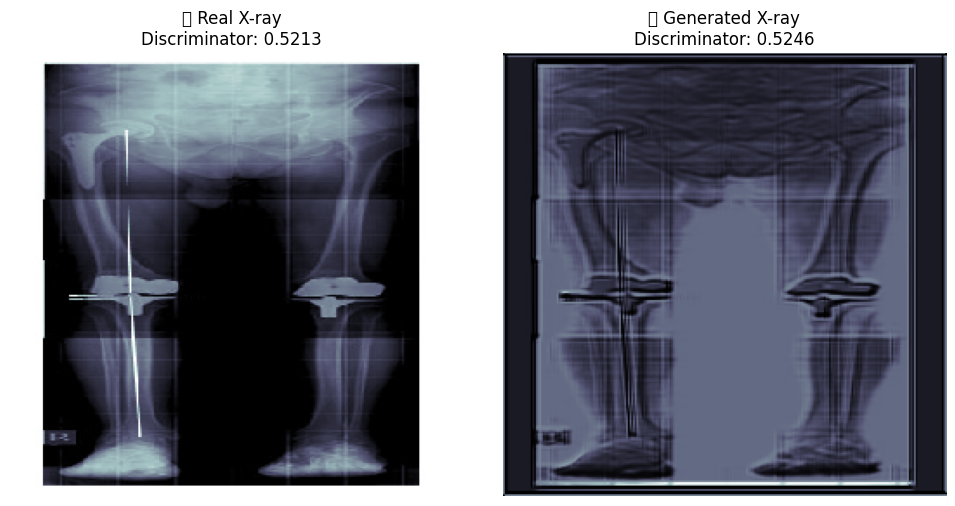

✅ Real Image Score: 0.5213
❌ Generated Image Score: 0.5246


In [ ]:
# Load trained models
generator = tf.keras.models.load_model("generator_model1.h5")
discriminator = tf.keras.models.load_model("discriminator_model1.h5")

# Define a sample caption
sample_caption = "Keratoconus with corneal thinning"

# Run the comparison
compare_real_vs_fake(sample_caption, tokenizer, generator, xray_images, train_padded, discriminator)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


<ipython-input-95-f15e0eaee1e8>:67: UserWarning: Glyph 129659 (\N{X-RAY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-95-f15e0eaee1e8>:67: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-95-f15e0eaee1e8>:67: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


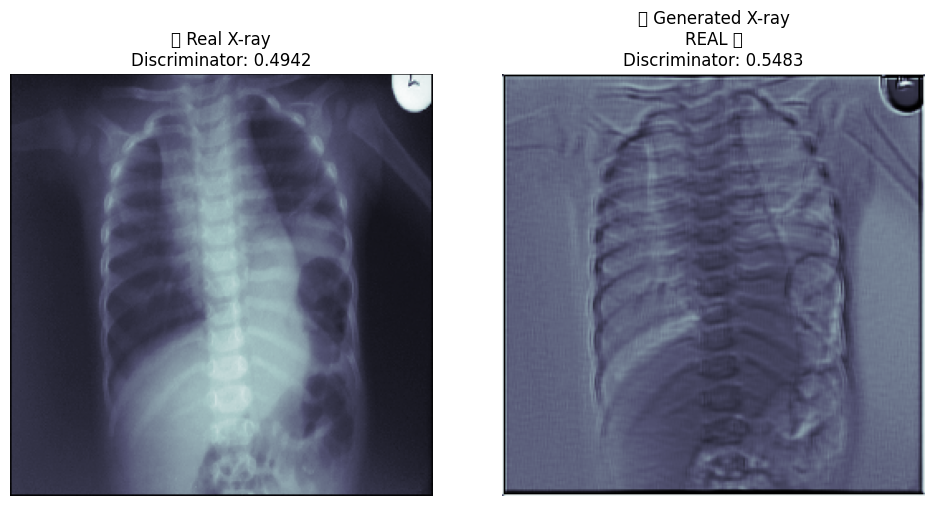

✅ Real Image Score: 0.4942
❌ Generated Image Score: 0.5483
🔎 Classification Result: REAL ✅


In [ ]:
# Load trained models
generator = tf.keras.models.load_model("generator_model1.h5")
discriminator = tf.keras.models.load_model("discriminator_model1.h5")

# Define a sample caption
sample_caption = "Keratoconus with corneal thinning"

# Run the comparison
compare_real_vs_fake(sample_caption, tokenizer, generator, xray_images, train_padded, discriminator)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


<ipython-input-90-f5fc2b3c4aa0>:61: UserWarning: Glyph 129659 (\N{X-RAY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-90-f5fc2b3c4aa0>:61: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


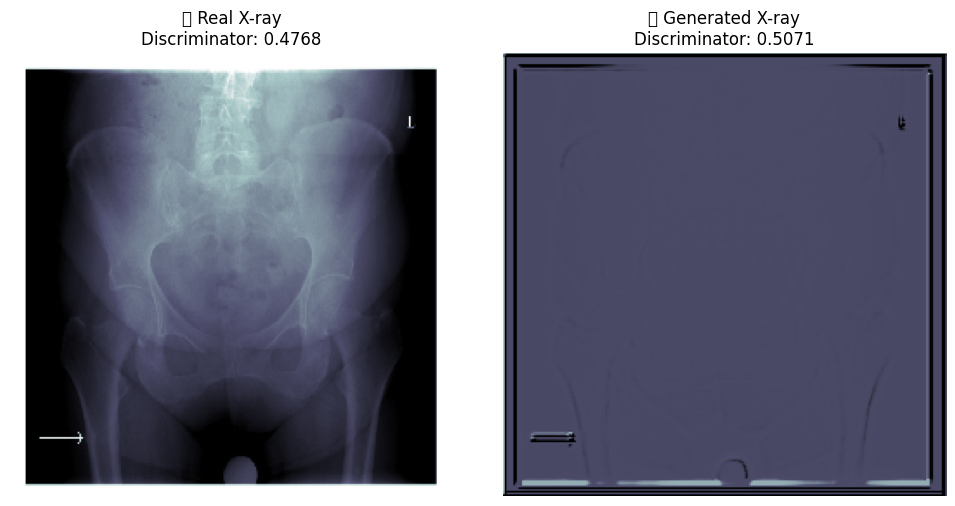

✅ Real Image Score: 0.4768
❌ Generated Image Score: 0.5071


In [ ]:
# Load trained models
generator = tf.keras.models.load_model("generator_model.h5")
discriminator = tf.keras.models.load_model("discriminator_model.h5")

# Define a sample caption
sample_caption = "Keratoconus with corneal thinning"

# Run the comparison
compare_real_vs_fake(sample_caption, tokenizer, generator, xray_images, train_padded, discriminator)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def compare_real_vs_fake(caption, tokenizer, generator_model, real_images, real_captions, discriminator_model=None, threshold=0.5):
    """
    Compare a real X-ray image with a generated (fake) one for the same caption and check if the generated image is fake.

    Args:
        caption (str): The text description for which we generate an image.
        tokenizer: The trained tokenizer for text preprocessing.
        generator_model: The trained generator model.
        real_images (numpy.ndarray): Array of real X-ray images.
        real_captions (numpy.ndarray): Tokenized real captions.
        discriminator_model: The trained discriminator model (optional).
        threshold (float): The decision threshold for classifying real vs. fake images.

    Returns:
        None (Displays the comparison plot and prints the classification result)
    """
    # ✅ Step 1: Preprocess Text Input
    processed_caption = preprocess_text(caption, tokenizer)

    # ✅ Step 2: Select a Real Image
    random_index = np.random.randint(0, len(real_captions))
    real_image = real_images[random_index]

    # Convert grayscale to 3-channel format if needed
    if len(real_image.shape) == 2:
        real_image = np.stack([real_image] * 3, axis=-1)

    # Add batch dimension
    real_image = np.expand_dims(real_image, axis=0)

    # ✅ Step 3: Generate Fake Image
    generated_image = generator_model.predict([processed_caption, real_image])
    generated_image = np.clip(generated_image[0], 0, 1)

    # Convert grayscale fake image to 3-channel format
    if generated_image.shape[-1] == 1:
        generated_image = np.repeat(generated_image, 3, axis=-1)

    # ✅ Step 4: Evaluate with Discriminator (Optional)
    real_score, fake_score = None, None
    classification_result = "Unknown"

    if discriminator_model:
        real_score = discriminator_model.predict(real_image)[0][0]
        fake_score = discriminator_model.predict(np.expand_dims(generated_image, axis=0))[0][0]

        # ✅ Classify Fake vs. Real
        classification_result = "FAKE ❌" if fake_score < threshold else "REAL ✅"

    # ✅ Step 5: Display the Comparison
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(np.mean(real_image[0], axis=-1), cmap="bone")
    plt.title(f"🩻 Real X-ray\nDiscriminator: {real_score:.4f}" if real_score else "🩻 Real X-ray")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(np.mean(generated_image, axis=-1), cmap="bone")
    plt.title(f"🖼️ Generated X-ray\n{classification_result}\nDiscriminator: {fake_score:.4f}" if fake_score else "🖼️ Generated X-ray")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # ✅ Print Discriminator's Decision
    if discriminator_model:
        print(f"✅ Real Image Score: {real_score:.4f}")
        print(f"❌ Generated Image Score: {fake_score:.4f}")
        print(f"🔎 Classification Result: {classification_result}")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


<ipython-input-95-f15e0eaee1e8>:67: UserWarning: Glyph 129659 (\N{X-RAY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-95-f15e0eaee1e8>:67: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-95-f15e0eaee1e8>:67: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


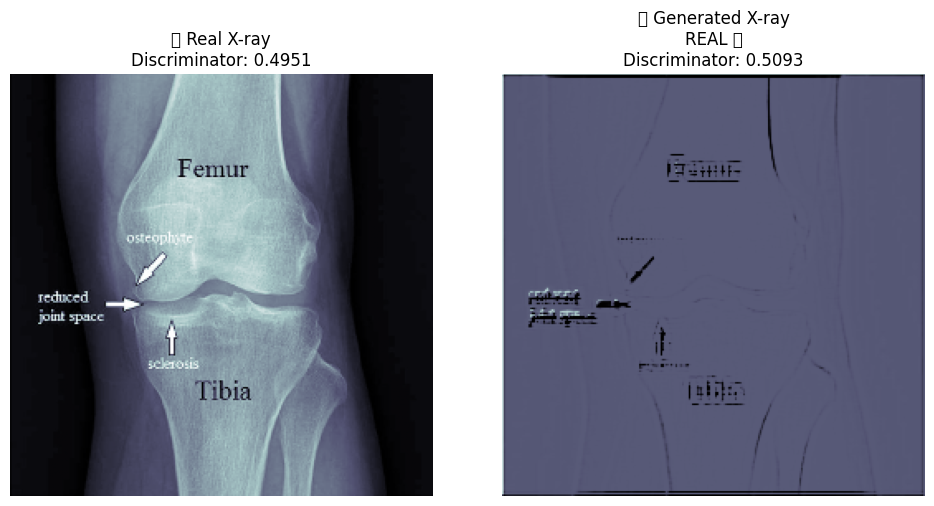

✅ Real Image Score: 0.4951
❌ Generated Image Score: 0.5093
🔎 Classification Result: REAL ✅


In [ ]:
# Load trained models
generator = tf.keras.models.load_model("generator_model.h5")
discriminator = tf.keras.models.load_model("discriminator_model.h5")

# Define a sample caption
sample_caption = "startseq plain abdomen xray multiple air level midabdomen arrow radiopaque shadow air diaphragm endseq"

# Run the comparison
compare_real_vs_fake(sample_caption, tokenizer, generator, xray_images, train_padded, discriminator)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 669ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


<ipython-input-95-f15e0eaee1e8>:67: UserWarning: Glyph 129659 (\N{X-RAY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-95-f15e0eaee1e8>:67: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-95-f15e0eaee1e8>:67: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


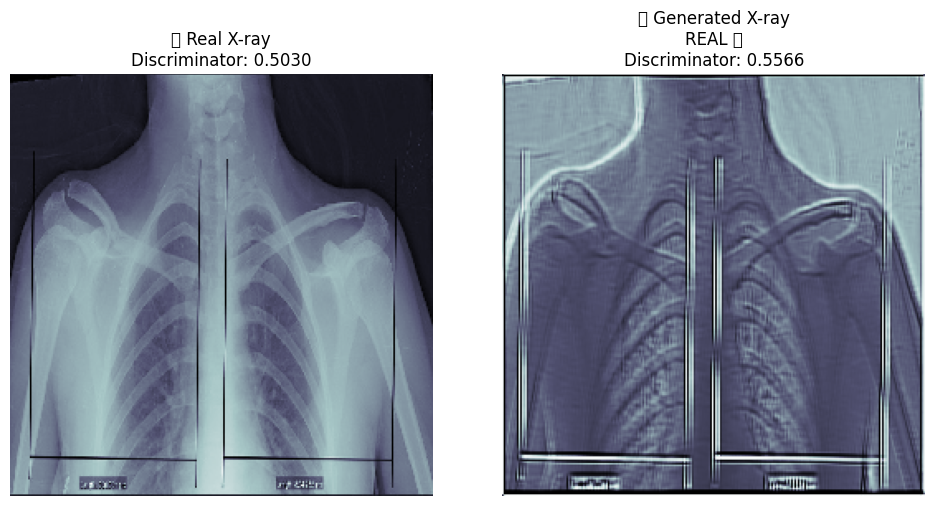

✅ Real Image Score: 0.5030
❌ Generated Image Score: 0.5566
🔎 Classification Result: REAL ✅


In [ ]:
# Load trained models
generator = tf.keras.models.load_model("generator_model1.h5")
discriminator = tf.keras.models.load_model("discriminator_model1.h5")

# Define a sample caption
sample_caption = "startseq plain abdomen xray multiple air level midabdomen arrow radiopaque shadow air diaphragm endseq"

# Run the comparison
compare_real_vs_fake(sample_caption, tokenizer, generator, xray_images, train_padded, discriminator)


Processed Caption (Tokenized): [[  2  73   5  40  39   1 278   1   1 125  59   3   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]]
Selected Real Image Index: 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


<ipython-input-104-cc8845372b06>:69: UserWarning: Glyph 129659 (\N{X-RAY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-104-cc8845372b06>:69: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-104-cc8845372b06>:69: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


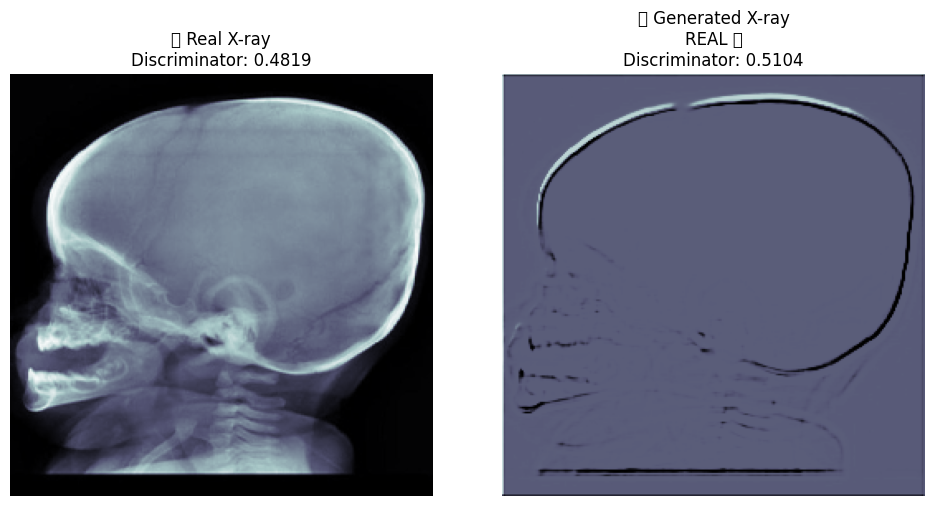

✅ Real Image Score: 0.4819
❌ Generated Image Score: 0.5104
🔎 Classification Result: REAL ✅


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def compare_real_vs_fake(caption, tokenizer, generator_model, real_images, real_captions, discriminator_model=None, threshold=0.5, fixed_index=0):
    """
    Compare a real X-ray image with a generated (fake) one for the same caption and check if the generated image is fake.

    Args:
        caption (str): The text description for which we generate an image.
        tokenizer: The trained tokenizer for text preprocessing.
        generator_model: The trained generator model.
        real_images (numpy.ndarray): Array of real X-ray images.
        real_captions (numpy.ndarray): Tokenized real captions.
        discriminator_model: The trained discriminator model (optional).
        threshold (float): The decision threshold for classifying real vs. fake images.
        fixed_index (int): Fixed index for selecting a real image instead of random selection.

    Returns:
        None (Displays the comparison plot and prints the classification result)
    """
    # ✅ Step 1: Preprocess Text Input
    processed_caption = preprocess_text(caption, tokenizer)
    print("Processed Caption (Tokenized):", processed_caption)

    # ✅ Step 2: Select a Real Image (Use Fixed Index for Consistency)
    real_image = real_images[fixed_index % len(real_captions)]
    print("Selected Real Image Index:", fixed_index)

    # Convert grayscale to 3-channel format if needed
    if len(real_image.shape) == 2:
        real_image = np.stack([real_image] * 3, axis=-1)

    # Add batch dimension
    real_image = np.expand_dims(real_image, axis=0)

    # ✅ Step 3: Generate Fake Image (Ensure Consistency)
    generated_image = generator_model.predict([processed_caption, real_image])
    generated_image = np.clip(generated_image[0], 0, 1)

    # Convert grayscale fake image to 3-channel format
    if generated_image.shape[-1] == 1:
        generated_image = np.repeat(generated_image, 3, axis=-1)

    # ✅ Step 4: Evaluate with Discriminator (Optional)
    real_score, fake_score = None, None
    classification_result = "Unknown"

    if discriminator_model:
        real_score = discriminator_model.predict(real_image, verbose=0)[0][0]
        fake_score = discriminator_model.predict(np.expand_dims(generated_image, axis=0), verbose=0)[0][0]

        # ✅ Classify Fake vs. Real
        classification_result = "FAKE ❌" if fake_score < threshold else "REAL ✅"

    # ✅ Step 5: Display the Comparison
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(np.mean(real_image[0], axis=-1), cmap="bone")
    plt.title(f"🩻 Real X-ray\nDiscriminator: {real_score:.4f}" if real_score else "🩻 Real X-ray")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(np.mean(generated_image, axis=-1), cmap="bone")
    plt.title(f"🖼️ Generated X-ray\n{classification_result}\nDiscriminator: {fake_score:.4f}" if fake_score else "🖼️ Generated X-ray")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # ✅ Print Discriminator's Decision
    if discriminator_model:
        print(f"✅ Real Image Score: {real_score:.4f}")
        print(f"❌ Generated Image Score: {fake_score:.4f}")
        print(f"🔎 Classification Result: {classification_result}")


# Load trained models
generator = tf.keras.models.load_model("generator_model.h5")
discriminator = tf.keras.models.load_model("discriminator_model.h5")

# Define a sample caption
sample_caption = "startseq normal chest X-ray with clear lungs and heart shadow endseq"

# Run the comparison with a fixed image index
compare_real_vs_fake(sample_caption, tokenizer, generator, xray_images, train_padded, discriminator, fixed_index=0)


Processed Caption (Tokenized): [[  2  73   5  40  39   1 278   1   1 125  59   3   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]]
Selected Real Image Index: 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step


<ipython-input-105-cecb6ca0d24a>:69: UserWarning: Glyph 129659 (\N{X-RAY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-105-cecb6ca0d24a>:69: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-105-cecb6ca0d24a>:69: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


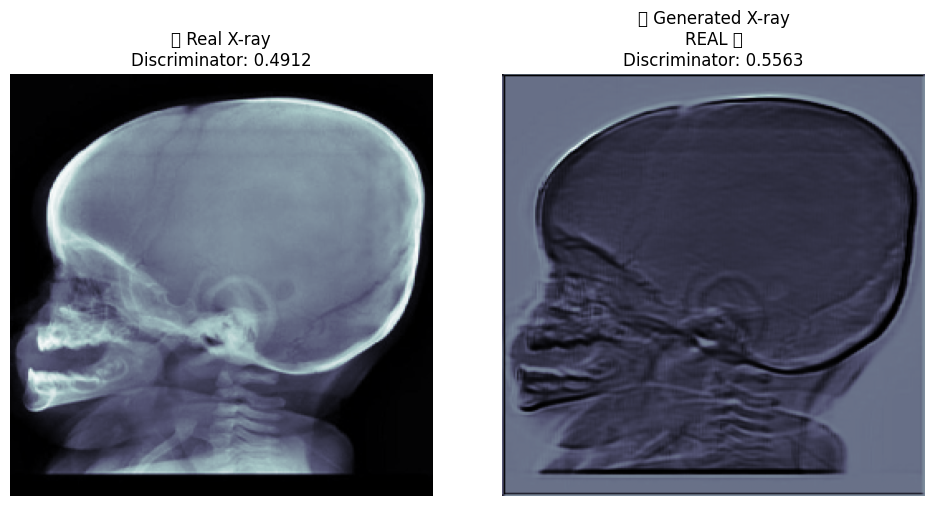

✅ Real Image Score: 0.4912
❌ Generated Image Score: 0.5563
🔎 Classification Result: REAL ✅


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def compare_real_vs_fake(caption, tokenizer, generator_model, real_images, real_captions, discriminator_model=None, threshold=0.5, fixed_index=0):
    """
    Compare a real X-ray image with a generated (fake) one for the same caption and check if the generated image is fake.

    Args:
        caption (str): The text description for which we generate an image.
        tokenizer: The trained tokenizer for text preprocessing.
        generator_model: The trained generator model.
        real_images (numpy.ndarray): Array of real X-ray images.
        real_captions (numpy.ndarray): Tokenized real captions.
        discriminator_model: The trained discriminator model (optional).
        threshold (float): The decision threshold for classifying real vs. fake images.
        fixed_index (int): Fixed index for selecting a real image instead of random selection.

    Returns:
        None (Displays the comparison plot and prints the classification result)
    """
    # ✅ Step 1: Preprocess Text Input
    processed_caption = preprocess_text(caption, tokenizer)
    print("Processed Caption (Tokenized):", processed_caption)

    # ✅ Step 2: Select a Real Image (Use Fixed Index for Consistency)
    real_image = real_images[fixed_index % len(real_captions)]
    print("Selected Real Image Index:", fixed_index)

    # Convert grayscale to 3-channel format if needed
    if len(real_image.shape) == 2:
        real_image = np.stack([real_image] * 3, axis=-1)

    # Add batch dimension
    real_image = np.expand_dims(real_image, axis=0)

    # ✅ Step 3: Generate Fake Image (Ensure Consistency)
    generated_image = generator_model.predict([processed_caption, real_image])
    generated_image = np.clip(generated_image[0], 0, 1)

    # Convert grayscale fake image to 3-channel format
    if generated_image.shape[-1] == 1:
        generated_image = np.repeat(generated_image, 3, axis=-1)

    # ✅ Step 4: Evaluate with Discriminator (Optional)
    real_score, fake_score = None, None
    classification_result = "Unknown"

    if discriminator_model:
        real_score = discriminator_model.predict(real_image, verbose=0)[0][0]
        fake_score = discriminator_model.predict(np.expand_dims(generated_image, axis=0), verbose=0)[0][0]

        # ✅ Classify Fake vs. Real
        classification_result = "FAKE ❌" if fake_score < threshold else "REAL ✅"

    # ✅ Step 5: Display the Comparison
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(np.mean(real_image[0], axis=-1), cmap="bone")
    plt.title(f"🩻 Real X-ray\nDiscriminator: {real_score:.4f}" if real_score else "🩻 Real X-ray")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(np.mean(generated_image, axis=-1), cmap="bone")
    plt.title(f"🖼️ Generated X-ray\n{classification_result}\nDiscriminator: {fake_score:.4f}" if fake_score else "🖼️ Generated X-ray")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # ✅ Print Discriminator's Decision
    if discriminator_model:
        print(f"✅ Real Image Score: {real_score:.4f}")
        print(f"❌ Generated Image Score: {fake_score:.4f}")
        print(f"🔎 Classification Result: {classification_result}")


# Load trained models
generator = tf.keras.models.load_model("generator_model1.h5")
discriminator = tf.keras.models.load_model("discriminator_model1.h5")

# Define a sample caption
sample_caption = "startseq normal chest X-ray with clear lungs and heart shadow endseq"

# Run the comparison with a fixed image index
compare_real_vs_fake(sample_caption, tokenizer, generator, xray_images, train_padded, discriminator, fixed_index=0)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def preprocess_caption(caption, tokenizer):
    """
    Convert a text caption into a tokenized sequence for input to the generator model.

    Args:
        caption (str): The text description.
        tokenizer: The trained tokenizer.

    Returns:
        numpy.ndarray: Tokenized caption sequence.
    """
    sequence = tokenizer.texts_to_sequences([caption])
    padded_sequence = tf.keras.preprocessing.sequence.pad_sequences(sequence, maxlen=136, padding='post')
    return np.array(padded_sequence)

def generate_image(caption, tokenizer, generator_model):
    """
    Generate an image from a given caption using the generator model.

    Args:
        caption (str): The text description.
        tokenizer: The trained tokenizer.
        generator_model: The trained generator model.

    Returns:
        numpy.ndarray: Generated image.
    """
    processed_caption = preprocess_caption(caption, tokenizer)

    # Sample a random noise vector (assuming latent dim = 100)
    noise = np.random.normal(0, 1, (1, 100))

    # Generate the image
    generated_image = generator_model.predict([processed_caption, noise], verbose=0)
    generated_image = np.clip(generated_image[0], 0, 1)

    return generated_image

def classify_image(image, discriminator_model, threshold=0.5):
    """
    Classify an image as real or fake using the discriminator model.

    Args:
        image (numpy.ndarray): The image to classify.
        discriminator_model: The trained discriminator model.
        threshold (float): Decision threshold.

    Returns:
        str: Classification result.
        float: Discriminator confidence score.
    """
    score = discriminator_model.predict(np.expand_dims(image, axis=0), verbose=0)[0][0]
    classification = "FAKE ❌" if score < threshold else "REAL ✅"
    return classification, score

def display_generated_image(caption, generated_image, real_image=None, discriminator_model=None):
    """
    Display the generated image alongside a real image if provided.

    Args:
        caption (str): The input caption.
        generated_image (numpy.ndarray): The generated image.
        real_image (numpy.ndarray, optional): The real image.
        discriminator_model: The trained discriminator model (optional).
    """
    fake_classification, fake_score = "Unknown", None

    if discriminator_model:
        fake_classification, fake_score = classify_image(generated_image, discriminator_model)

    fig, axes = plt.subplots(1, 2 if real_image is not None else 1, figsize=(12, 6))

    if real_image is not None:
        # Display Real X-ray Image
        axes[0].imshow(np.mean(real_image, axis=-1), cmap="bone")
        axes[0].set_title("🩻 Real X-ray")
        axes[0].axis("off")

        # Display Generated Image
        axes[1].imshow(np.mean(generated_image, axis=-1), cmap="bone")
        axes[1].set_title(f"🖼️ Generated X-ray\n{fake_classification}")
        axes[1].axis("off")
    else:
        # Only Generated Image
        axes.imshow(np.mean(generated_image, axis=-1), cmap="bone")
        axes.set_title(f"🖼️ Generated X-ray\n{fake_classification}")
        axes.axis("off")

    plt.suptitle(f"📝 Caption: {caption}", fontsize=14, fontweight="bold", color="black")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    # Print classification result
    if discriminator_model:
        print(f"🔎 Classification Result:   {fake_classification}")
        print(f"❌ Generated Image Score: {fake_score:.4f}")

# Load trained models
generator = tf.keras.models.load_model("generator_model1.h5")
discriminator = tf.keras.models.load_model("discriminator_model1.h5")

# Define a sample caption
sample_caption = "startseq chest X-ray with a properly positioned endotracheal tube above the carina endseq"

# Generate image
generated_img = generate_image(sample_caption, tokenizer, generator)

# Display only the generated image
display_generated_image(sample_caption, generated_img, discriminator_model=discriminator)


ValueError: Input 1 of layer "AttnGAN_Generator" is incompatible with the layer: expected shape=(None, 256, 256, 3), found shape=(1, 100)

## `test embedding layers`

In [ ]:
import pickle
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load the tokenizer
with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

# Sample test sentence
test_sentence = "plain abdomen xray multiple air level midabdomen arrow radiopaque shadow air diaphragm"

# Convert to sequence
test_sequence = tokenizer.texts_to_sequences([test_sentence])
print("Tokenized Sequence:", test_sequence)

# Pad sequence
max_length = 20  # Same as used before
padded_test_sequence = pad_sequences(test_sequence, maxlen=max_length, padding="post")
print("Padded Sequence:", padded_test_sequence)


Tokenized Sequence: [[21, 45, 4, 48, 51, 47, 1722, 10, 296, 59, 51, 108]]
Padded Sequence: [[  21   45    4   48   51   47 1722   10  296   59   51  108    0    0
     0    0    0    0    0    0]]


In [ ]:
# Load the embedding matrix
embedding_matrix = np.load("embedding_matrix.npy")

print("Embedding Matrix Shape:", embedding_matrix.shape)  # Should be (vocab_size, embedding_dim)

# Print a sample word embedding
word_index = tokenizer.word_index
word = "plain"

if word in word_index:
    word_id = word_index[word]
    print(f"Embedding for '{word}':", embedding_matrix[word_id])
else:
    print(f"'{word}' not found in tokenizer vocabulary.")


Embedding Matrix Shape: (5839, 300)
Embedding for 'plain': [0.73245606 0.30797628 0.61806836 0.61341098 0.35797606 0.0928209
 0.82298722 0.45776681 0.81606282 0.44342053 0.05060438 0.05225855
 0.76274389 0.21979335 0.71728942 0.20978426 0.63920378 0.91362147
 0.32593194 0.24168927 0.89008374 0.24941374 0.55647781 0.31951406
 0.0362221  0.47966686 0.88878386 0.38927438 0.1788258  0.09439072
 0.26165037 0.14074243 0.7478851  0.49769671 0.65336783 0.15574042
 0.50366119 0.54999512 0.95547846 0.60747753 0.99943526 0.7225996
 0.87344997 0.27895919 0.09823182 0.07937967 0.52529503 0.90393448
 0.28044838 0.68102217 0.32998383 0.16873868 0.20625797 0.60461068
 0.37471336 0.38298984 0.94197654 0.892631   0.46635331 0.89632405
 0.90749364 0.17107702 0.24531648 0.07553886 0.77236429 0.38237897
 0.38211473 0.89062616 0.61184812 0.79821913 0.04258423 0.56002689
 0.25738537 0.91406238 0.55023689 0.69525026 0.71713107 0.95365873
 0.36849383 0.10920947 0.60348335 0.9107091  0.17087421 0.69318075
 0.29

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Embedding

# Create embedding layer with loaded weights
vocab_size, embedding_dim = embedding_matrix.shape
embedding_layer = Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length, weights=[embedding_matrix], trainable=False)

# Run test sentence through embedding
embedded_output = embedding_layer(padded_test_sequence)
print("Embedded Output Shape:", embedded_output.shape)


Embedded Output Shape: (1, 20, 300)
